,day,hour,irradiance,temperature,hydrogen_kg,sth_efficiency,cost,losses,modules_series,modules_parallel,cells_series,cells_parallel,pem_temperature
0,1,7,154,5.09,2.327891,0.133300,2309420,2940.823314,6,297,108,1,334
1,1,7,154,5.09,3.662950,0.136612,2605160,6.166519,6,456,108,1,334
2,1,7,154,5.09,4.477783,0.136230,2796740,644.405323,6,559,108,1,334
3,1,7,154,5.09,2.213944,0.134472,2277800,1792.700373,6,280,108,1,345
4,1,7,154,5.09,4.072163,0.134999,2711180,2477.199001,6,513,108,1,335


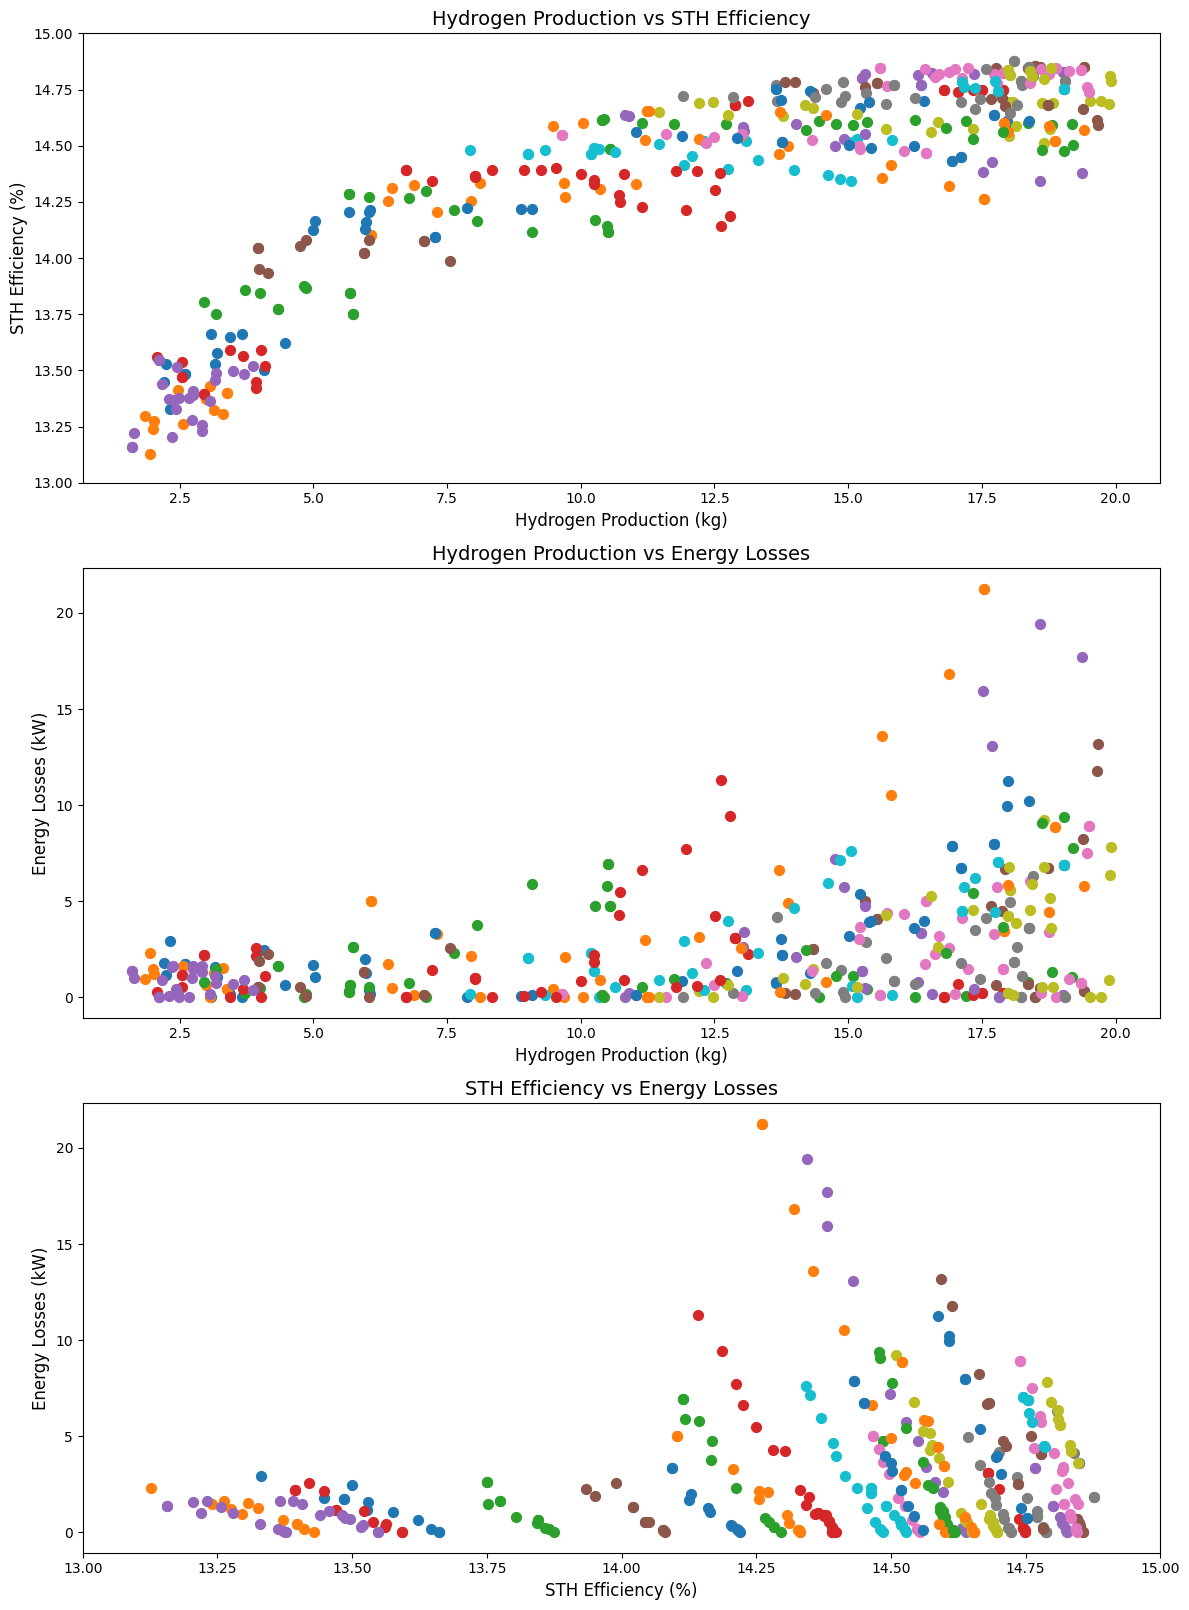

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [58]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd

df_summary = pd.read_csv('nsga2_summary_1MW.csv')
display(df_summary.head())

# Reconstruct all_results_flex from df_summary
# This assumes df_summary was created from a similar structure as described in the user's provided snippet
grouped = df_summary.groupby(['day', 'hour', 'irradiance', 'temperature'])

all_results_flex = []
for name, group in grouped:
    day, hour, irradiance, temperature = name

    pareto_front_list = []
    pareto_solutions_list = []

    for index, row in group.iterrows():
        f1 = -row['hydrogen_kg']
        f2 = -row['sth_efficiency']
        f3 = row['cost']
        f4 = row['losses']
        pareto_front_list.append([f1, f2, f3, f4])

        s0 = row['modules_series']
        s1 = row['modules_parallel']
        s2 = row['cells_series']
        s3 = row['cells_parallel']
        s4 = row['pem_temperature']
        pareto_solutions_list.append([s0, s1, s2, s3, s4])

    all_results_flex.append({
        "day": day,
        "hour": hour,
        "irradiance": irradiance,
        "temperature": temperature,
        "pareto_front": np.array(pareto_front_list),
        "pareto_solutions": np.array(pareto_solutions_list)
    })


plt.figure(figsize=(12, 18))  # Adjusted figure size for 3 full-height plots

# -----------------------------
# Plot 1: Hydrogen Production vs STH Efficiency
ax1 = plt.subplot(3, 1, 1)  # 3 rows, 1 column, 1st plot
for result in all_results_flex:
    pareto_front = np.array(result['pareto_front'])

    H2 = -pareto_front[:, 0]   # Hydrogen Production
    STH = -pareto_front[:, 1]*100  # STH Efficiency

    # Filter STH within limits
    mask = (STH >= 13) & (STH <= 15)
    ax1.scatter(H2[mask], STH[mask], label=f"Day {result['day']}, Hour {result['hour']}", s=50)

ax1.set_title('Hydrogen Production vs STH Efficiency', fontsize=14)
ax1.set_xlabel('Hydrogen Production (kg)', fontsize=12)
ax1.set_ylabel('STH Efficiency (%)', fontsize=12)
ax1.set_ylim(13, 15)  # Force STH axis limits
ax1.grid(False)

# -----------------------------
# Plot 2: Hydrogen Production vs Energy Losses
ax2 = plt.subplot(3, 1, 2)  # 3 rows, 1 column, 2nd plot
for result in all_results_flex:
    pareto_front = np.array(result['pareto_front'])

    H2 = -pareto_front[:, 0]   # Hydrogen Production
    Loss = pareto_front[:, 3]/1000  # Energy Losses in kW

    ax2.scatter(H2, Loss, label=f"Day {result['day']}, Hour {result['hour']}", s=50)

ax2.set_title('Hydrogen Production vs Energy Losses', fontsize=14)
ax2.set_xlabel('Hydrogen Production (kg)', fontsize=12)
ax2.set_ylabel('Energy Losses (kW)', fontsize=12)
ax2.grid(False)

# -----------------------------
# Plot 3: STH Efficiency vs Energy Losses
ax3 = plt.subplot(3, 1, 3)  # 3 rows, 1 column, 3rd plot
for result in all_results_flex:
    pareto_front = np.array(result['pareto_front'])

    STH = -pareto_front[:, 1]*100  # STH Efficiency
    Loss = pareto_front[:, 3]/1000  # Energy Losses

    # Filter STH within limits
    mask = (STH >= 13) & (STH <= 15)
    ax3.scatter(STH[mask], Loss[mask], label=f"Day {result['day']}, Hour {result['hour']}", s=50)

ax3.set_title('STH Efficiency vs Energy Losses', fontsize=14)
ax3.set_xlabel('STH Efficiency (%)', fontsize=12)
ax3.set_ylabel('Energy Losses (kW)', fontsize=12)
ax3.set_xlim(13, 15)  # Force STH axis limits
ax3.grid(False)

# -----------------------------
plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.savefig("Comparison_of_Pareto_PEM_flex_3plots.png", dpi=300)
plt.show()
from google.colab import files
files.download("Comparison_of_Pareto_PEM_flex_3plots.png")

Average CRITIC weights (H2, STH, COST, LOSS): [0.2938 0.0382 0.5259 0.1421]
FUZZY-derived average weights: [0.1358 0.2272 0.3184 0.3186]  (n=35)
TOPSIS-derived average weights: [0.1428 0.2285 0.3124 0.3162]  (n=35)

Weight stability table (grouped by irradiance scenario):
Scenario Method  n  w_H2_mean  w_H2_std  w_STH_mean  w_STH_std  w_COST_mean  w_COST_std  w_LOSS_mean  w_LOSS__std  Stable(<0.05_all)
     low  FUZZY 12     0.0477    0.0381      0.1570     0.0783       0.4019      0.0583       0.3934       0.0595              False
     low TOPSIS 12     0.0477    0.0381      0.1570     0.0783       0.4019      0.0583       0.3934       0.0595              False
  medium  FUZZY 11     0.1506    0.0167      0.2609     0.0040       0.2847      0.0186       0.3039       0.0153               True
  medium TOPSIS 11     0.1571    0.0268      0.2622     0.0060       0.2773      0.0300       0.3034       0.0155               True
    high  FUZZY 12     0.2102    0.0289      0.2666     0.0027

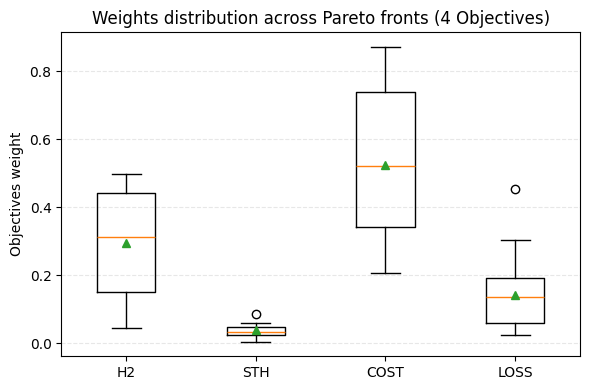

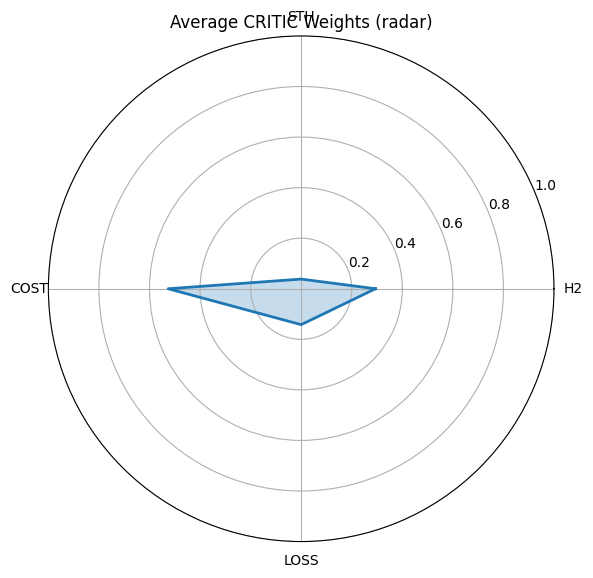

In [59]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# all_results_flex is already available from previous cell execution

PLOT_WEIGHTS = True
SAVE_FIG_PREFIX = "mcda_weights"

# The conversion to numpy arrays is already handled during the reconstruction in the previous cell.
# for res in all_results_flex:
#     res["pareto_front"] = np.array(res["pareto_front"], dtype=float)
#     if "pareto_solutions" in res:
#         res["pareto_solutions"] = np.array(res["pareto_solutions"], dtype=float)


# -----------------------------
# USER: supply all_results_flex (list of dicts)
# Each dict must contain:
#  - 'pareto_front' : Nx4 array-like with [f1, f2, f3, f4]  (stored format: [-H2, -STH, +Cost, +Loss])
#  - optional: 'pareto_solutions' (decision vectors) if you want to store solutions too
#  - optional: 'irradiance' scalar (used for scenario grouping below)
# -----------------------------

# -----------------------------
# Constants / Objective indices
# Stored objective format: [f1, f2, f3, f4] =
#   [-H2, -STH, +Cost, +Loss]
OBJ_H2 = 0
OBJ_STH = 1
OBJ_COST = 2
OBJ_LOSS = 3
M = 4
EPS = 1e-12
VIKOR_V = 0.5

# -----------------------------
# Helper: convert stored objective vector to "maximize" form
def to_maximize_array(arr):
    # arr: (...,4)
    a = np.array(arr, dtype=float)
    # invert where necessary so larger = better
    a_max = a.copy()
    a_max[..., OBJ_H2] = -a[..., OBJ_H2]
    a_max[..., OBJ_STH] = -a[..., OBJ_STH]
    a_max[..., OBJ_COST] = -a[..., OBJ_COST]   # cost invert -> lower cost becomes larger after invert
    a_max[..., OBJ_LOSS] = -a[..., OBJ_LOSS]
    return a_max

# -----------------------------
# Build global ranges using all pareto points
all_maximize = []
for res in all_results_flex:
    pf = res.get('pareto_front', None)
    if pf is None:
        continue
    pf = np.array(pf, dtype=float)
    if pf.size == 0:
        continue
    all_maximize.append(to_maximize_array(pf))
if len(all_maximize) == 0:
    raise RuntimeError("No pareto_front data found in all_results_flex.")
all_maximize = np.vstack(all_maximize).reshape(-1, M)

global_min = np.nanmin(all_maximize, axis=0)
global_max = np.nanmax(all_maximize, axis=0)
global_range = global_max - global_min
global_range[global_range == 0] = EPS

# -----------------------------
# prepare X_norm for a given pareto front using global scaling (0..1, higher better)
def prepare_objectives_global(pareto_front):
    P = np.array(pareto_front, dtype=float)
    P_max = to_maximize_array(P)   # Nx4 with maximize orientation
    X_norm = (P_max - global_min) / global_range
    # clip small numerical out-of-bounds
    X_norm = np.clip(X_norm, 0.0, 1.0)
    return X_norm

# -----------------------------
# CRITIC weights (robust)
def critic_weights(X_norm):
    # X_norm: NxM (higher better)
    # std
    std = np.nanstd(X_norm, axis=0, ddof=0)
    # correlation: handle degenerate by using np.nan_to_num
    with np.errstate(invalid='ignore'):
        corr = np.corrcoef(X_norm, rowvar=False)
    if corr.shape != (M, M):
        # degenerate: fallback
        corr = np.eye(M)
    if np.isnan(corr).any():
        corr = np.nan_to_num(corr, nan=0.0)
    # conflict measure
    conflict = np.sum(1.0 - corr, axis=0)
    C = std * conflict
    if np.allclose(C, 0):
        return np.ones(M) / M
    weights = C / (np.sum(C) + EPS)
    return weights

# -----------------------------
# TOPSIS, VIKOR, Fuzzy implementations (operate on X_norm)
def topsis_rank(X_norm, weights):
    W = np.asarray(weights)
    V = X_norm * W
    ideal = np.max(V, axis=0)
    nadir = np.min(V, axis=0)
    D_plus = np.linalg.norm(V - ideal, axis=1)
    D_minus = np.linalg.norm(V - nadir, axis=1)
    C = D_minus / (D_plus + D_minus + EPS)
    order = np.argsort(-C)
    return C, order

def vikor_rank(X_norm, weights, v=VIKOR_V):
    W = np.asarray(weights)
    ideal = np.max(X_norm, axis=0)
    nadir = np.min(X_norm, axis=0)
    denom = ideal - nadir
    denom[denom == 0] = EPS
    diff = (ideal - X_norm) / denom
    S = np.sum(W * diff, axis=1)
    R = np.max(W * diff, axis=1)
    S_min, S_max = np.min(S), np.max(S)
    R_min, R_max = np.min(R), np.max(R)
    S_range = S_max - S_min if S_max - S_min != 0 else EPS
    R_range = R_max - R_min if R_max - R_min != 0 else EPS
    Q = v * (S - S_min) / S_range + (1 - v) * (R - R_min) / R_range
    order = np.argsort(Q)
    return Q, order

def fuzzy_score(X_norm, weights):
    W = np.asarray(weights)
    scores = X_norm.dot(W)
    order = np.argsort(-scores)
    return scores, order

# -----------------------------
# MAIN loop: compute per-episode MCDA winners and CRITIC weights
critic_weights_all = []
fuzzy_best_idx = []
topsis_best_idx = []
vikor_best_idx = []
critic_best_idx = []
hybrid_best_idx = []
method_scores_storage = []

for r in all_results_flex:
    pf = r.get('pareto_front', None)
    if pf is None or len(pf) == 0:
        # fill placeholders
        r['critic_weights'] = np.array([np.nan]*M)
        r['fuzzy_best_index'] = None
        r['topsis_best_index'] = None
        r['vikor_best_index'] = None
        r['critic_best_index'] = None
        r['hybrid_best_index'] = None
        continue

    X_norm = prepare_objectives_global(pf)  # Nx4 normalized globally

    # CRITIC weights for this front
    w = critic_weights(X_norm)
    r['critic_weights'] = w
    critic_weights_all.append(w)

    # CRITIC selection: compute weighted score on X_norm (not raw)
    weighted_scores_critic = X_norm.dot(w)
    best_idx_critic = int(np.nanargmax(weighted_scores_critic))
    r['critic_best_index'] = best_idx_critic
    r['critic_best_solution'] = r.get('pareto_solutions', [None]*len(pf))[best_idx_critic]
    r['critic_best_objectives'] = r['pareto_front'][best_idx_critic]
    critic_best_idx.append(best_idx_critic)

    # Apply TOPSIS / VIKOR / Fuzzy using same weights and X_norm
    fuzzy_scores, fuzzy_order = fuzzy_score(X_norm, w)
    topsis_scores, topsis_order = topsis_rank(X_norm, w)
    vikor_scores, vikor_order = vikor_rank(X_norm, w)

    idx_fuzzy = int(fuzzy_order[0])
    idx_topsis = int(topsis_order[0])
    idx_vikor = int(vikor_order[0])

    r['fuzzy_best_index'] = idx_fuzzy
    r['topsis_best_index'] = idx_topsis
    r['vikor_best_index'] = idx_vikor

    r['fuzzy_best_solution'] = r.get('pareto_solutions', [None]*len(pf))[idx_fuzzy]
    r['topsis_best_solution'] = r.get('pareto_solutions', [None]*len(pf))[idx_topsis]
    r['vikor_best_solution'] = r.get('pareto_solutions', [None]*len(pf))[idx_vikor]

    r['fuzzy_best_objectives'] = r['pareto_front'][idx_fuzzy]
    r['topsis_best_objectives'] = r['pareto_front'][idx_topsis]
    r['vikor_best_objectives'] = r['pareto_front'][idx_vikor]

    # Hybrid majority vote (fuzzy, topsis, vikor). Tie-break by highest TOPSIS closeness
    votes = [idx_fuzzy, idx_topsis, idx_vikor]
    counts = Counter(votes)
    most = counts.most_common()
    top_count = most[0][1]
    tied = [it for it, ct in most if ct == top_count]
    if len(tied) == 1:
        final_idx = tied[0]
    else:
        # choose tied alternative with highest topsis score C
        final_idx = max(tied, key=lambda ix: topsis_scores[ix])
    r['hybrid_best_index'] = int(final_idx)
    r['hybrid_best_solution'] = r.get('pareto_solutions', [None]*len(pf))[final_idx]
    r['hybrid_best_objectives'] = r['pareto_front'][final_idx]

    hybrid_best_idx.append(final_idx)

    method_scores_storage.append({
        'fuzzy_scores': fuzzy_scores,
        'topsis_scores': topsis_scores,
        'vikor_Q': vikor_scores
    })

# finalize average CRITIC weights
if critic_weights_all:
    critic_weights_all = np.array(critic_weights_all)
    average_critic_weights = np.nanmean(critic_weights_all, axis=0)
else:
    average_critic_weights = np.array([np.nan]*M)

print("Average CRITIC weights (H2, STH, COST, LOSS):", np.round(average_critic_weights, 4))

# -----------------------------
# DERIVE weights from each MCDA winner (per-episode) using global scaling
def derive_weights_from_obj_vector(obj_vector):
    # obj_vector is stored format [-H2, -STH, +Cost, +Loss]
    v = to_maximize_array(obj_vector)
    norm = (v - global_min) / global_range
    norm = np.clip(norm, 0.0, 1.0)
    if np.allclose(norm, 0):
        return np.ones(M) / M
    w = norm / (np.sum(norm) + EPS)
    return w

fuzzy_weights_list = []
topsis_weights_list = []

for r in all_results_flex:
    fo = r.get('fuzzy_best_objectives', None)
    to = r.get('topsis_best_objectives', None)
    if fo is not None:
        w = derive_weights_from_obj_vector(fo)
        fuzzy_weights_list.append(w)
        r['fuzzy_derived_weights'] = w
    if to is not None:
        w = derive_weights_from_obj_vector(to)
        topsis_weights_list.append(w)
        r['topsis_derived_weights'] = w

fuzzy_weights_arr = np.array(fuzzy_weights_list) if fuzzy_weights_list else np.empty((0, M))
topsis_weights_arr = np.array(topsis_weights_list) if topsis_weights_list else np.empty((0, M))

fuzzy_avg = np.nanmean(fuzzy_weights_arr, axis=0) if fuzzy_weights_arr.size else np.array([np.nan]*M)
topsis_avg = np.nanmean(topsis_weights_arr, axis=0) if topsis_weights_arr.size else np.array([np.nan]*M)

print("FUZZY-derived average weights:", np.round(fuzzy_avg,4), " (n={})".format(fuzzy_weights_arr.shape[0]))
print("TOPSIS-derived average weights:", np.round(topsis_avg,4), " (n={})".format(topsis_weights_arr.shape[0]))

# -----------------------------
# VALIDATION: group episodes into irradiance scenarios (low/med/high) and compute stability table
# If your results already include a 'scenario' key, you may use that instead of irradiance bins.
irr_vals = np.array([res.get('irradiance', np.nan) for res in all_results_flex])
# define bins on available irradiance percentiles
valid_mask = ~np.isnan(irr_vals)
if np.sum(valid_mask) >= 3:
    p33, p66 = np.nanpercentile(irr_vals[valid_mask], [33, 66])
else:
    # fallback simple bins
    p33, p66 = np.nanmin(irr_vals), np.nanmax(irr_vals)

def scenario_label(irr):
    if np.isnan(irr): return 'unknown'
    if irr <= p33: return 'low'
    if irr <= p66: return 'medium'
    return 'high'

scenarios = {'low': [], 'medium': [], 'high': []}

# collect derived weights per scenario and method
for res in all_results_flex:
    lab = scenario_label(res.get('irradiance', np.nan))
    if lab == 'unknown': continue
    if 'fuzzy_derived_weights' in res:
        scenarios[lab].append(('fuzzy', res['fuzzy_derived_weights']))
    if 'topsis_derived_weights' in res:
        scenarios[lab].append(('topsis', res['topsis_derived_weights']))

# build table rows
rows = []
for lab in ['low','medium','high']:
    # collect arrays
    fuzzy_ws = [w for method,w in scenarios[lab] if method=='fuzzy']
    topsis_ws = [w for method,w in scenarios[lab] if method=='topsis']
    def summarize(arr):
        if len(arr)==0:
            return (np.array([np.nan]*M), np.array([np.nan]*M))
        A = np.vstack(arr)
        return np.nanmean(A,axis=0), np.nanstd(A,axis=0)
    f_mean, f_std = summarize(fuzzy_ws)
    t_mean, t_std = summarize(topsis_ws)
    # stability check: each method compared to its overall mean, max delta < 0.05 (5%)
    def stable(mean_arr, overall_arr):
        if np.isnan(mean_arr).any() or np.isnan(overall_arr).any(): return False
        return np.max(np.abs(mean_arr - overall_arr)) < 0.05
    rows.append({
        'scenario': lab,
        'method': 'FUZZY',
        'mean': f_mean,
        'std': f_std,
        'n': len(fuzzy_ws),
        'stable': stable(f_mean, fuzzy_avg)
    })
    rows.append({
        'scenario': lab,
        'method': 'TOPSIS',
        'mean': t_mean,
        'std': t_std,
        'n': len(topsis_ws),
        'stable': stable(t_mean, topsis_avg)
    })

# present DataFrame
df_rows = []
for r in rows:
    mean = r['mean']
    std = r['std']
    df_rows.append({
        'Scenario': r['scenario'],
        'Method': r['method'],
        'n': r['n'],
        'w_H2_mean': np.round(mean[0],4),
        'w_H2_std': np.round(std[0],4),
        'w_STH_mean': np.round(mean[1],4),
        'w_STH_std': np.round(std[1],4),
        'w_COST_mean': np.round(mean[2],4),
        'w_COST_std': np.round(std[2],4),
        'w_LOSS_mean': np.round(mean[3],4),
        'w_LOSS__std': np.round(std[3],4),
        'Stable(<0.05_all)': r['stable']
    })
df = pd.DataFrame(df_rows)
print("\nWeight stability table (grouped by irradiance scenario):")
print(df.to_string(index=False))

# Optionally save as CSV for inclusion in manuscript
df.to_csv("mcda_weight_stability_table.csv", index=False)
print("\nSaved mcda_weight_stability_table.csv")

# Optional: show small table of first N per-episode weights for inspection
N = 5
# --- Compute final aggregated weights across all episodes ---
if fuzzy_weights_arr.size:
    fuzzy_weights_final = np.mean(fuzzy_weights_arr, axis=0)
    print("\nFinal Fuzzy Weights (averaged across episodes):")
    print(fuzzy_weights_final)

if topsis_weights_arr.size:
    topsis_weights_final = np.mean(topsis_weights_arr, axis=0)
    print("\nFinal TOPSIS Weights (averaged across episodes):")
    print(topsis_weights_final)

# finalize average weights
if len(critic_weights_all) > 0:
    critic_weights_all = np.array(critic_weights_all)
    average_weights = np.nanmean(critic_weights_all, axis=0)
else:
    average_weights = np.array([np.nan, np.nan, np.nan, np.nan])

w_H2, w_STH, w_COST, w_LOSS = average_weights
print("\n🎯 CRITIC average objective weights (order = [H2, STH, Cost, Loss]):")
print(average_weights)
print(f"H2={w_H2:.3f}, STH={w_STH:.3f}, COST={w_COST:.3f}, LOSS={w_LOSS:.3f}")

# -----------------------------
# Optional: Visualize weight distribution
# -----------------------------
if PLOT_WEIGHTS and len(critic_weights_all) > 0:
    # Boxplot of per-front weights
    plt.figure(figsize=(6,4))
    labels = ['H2','STH','COST','LOSS']
    plt.boxplot(critic_weights_all, tick_labels=labels, showmeans=True)
    plt.title('Weights distribution across Pareto fronts (4 Objectives)')
    plt.ylabel('Objectives weight')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{SAVE_FIG_PREFIX}_boxplot.png", dpi=150)
    print(f"Saved weight boxplot: {SAVE_FIG_PREFIX}_boxplot.png")

    # Radar chart (average weights)
    # Prepare data for radar
    avg = average_weights
    # duplicate first value to close the polygon
    radar_vals = np.concatenate([avg, avg[:1]])
    angles = np.linspace(0, 2*np.pi, len(avg)+1, endpoint=True)

    fig, ax = plt.subplots(subplot_kw=dict(polar=True), figsize=(6,6))
    ax.plot(angles, radar_vals, linewidth=2)
    ax.fill(angles, radar_vals, alpha=0.25)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    ax.set_ylim(0, np.max([1.0, np.max(avg)*1.1]))
    ax.set_title('Average CRITIC Weights (radar)')
    plt.tight_layout()
    plt.savefig(f"{SAVE_FIG_PREFIX}_radar_new.png", dpi=150)
    print(f"Saved radar chart: {SAVE_FIG_PREFIX}_radar_new.png")

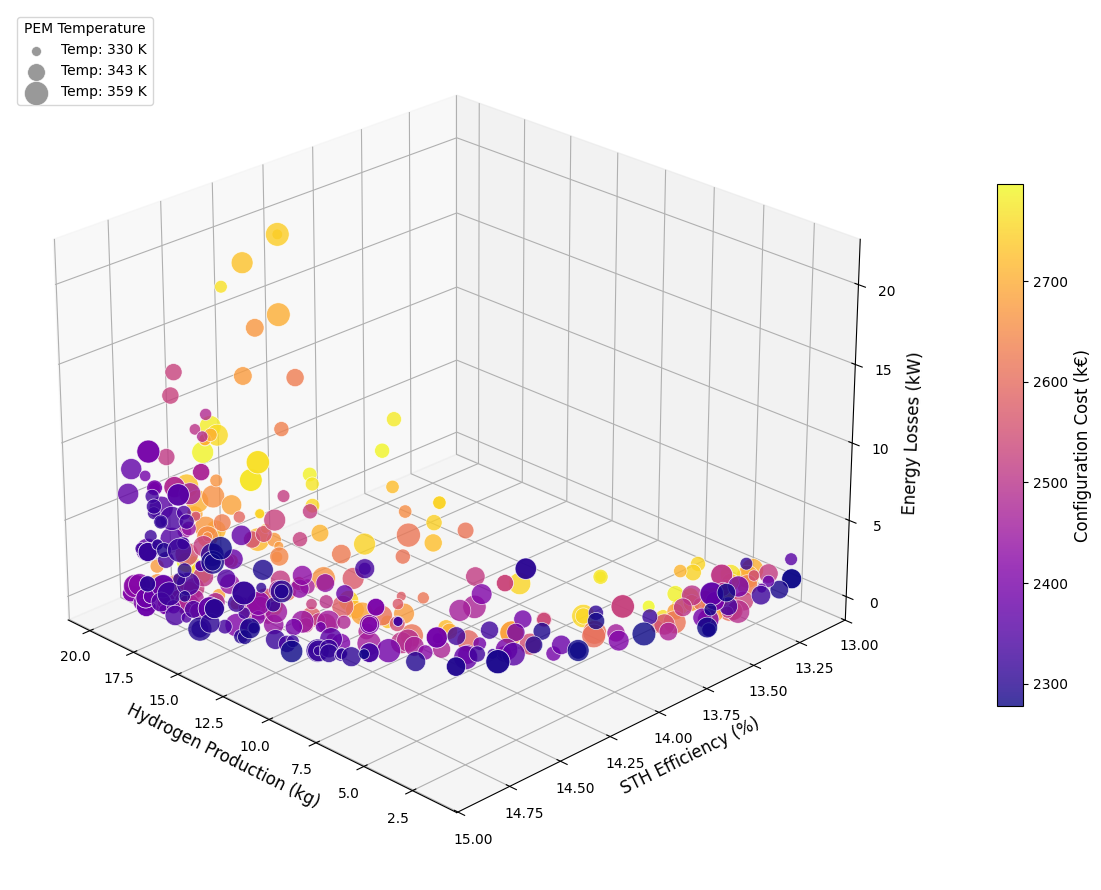

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [60]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

# --- 3D Pareto Front Plot with Losses as Z and Cost as color, Temperature as size ---
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Collect data for all points for proper scaling of temperature and cost
all_H2 = []
all_STH = []
all_Loss = []
all_Cost = []
all_PEM_Temp = []

for result in all_results_flex:
    if 'pareto_front' not in result or 'pareto_solutions' not in result:
        continue

    pareto_front = np.array(result['pareto_front'])
    pareto_solutions = np.array(result['pareto_solutions'])

    H2 = -pareto_front[:, 0]    # Hydrogen Production
    STH = -pareto_front[:, 1]*100   # STH Efficiency
    Loss = pareto_front[:, 3]/1000   # Energy Losses (Z-axis)
    Cost = pareto_front[:, 2] / 1000  # Economic Cost (for color), converted to k€
    PEM_Temp = pareto_solutions[:, 4] # PEM Temperature (for size)

    # -----------------------------
    # Apply STH limits
    mask = (STH >= 13) & (STH <= 15)
    H2 = H2[mask]
    STH = STH[mask]
    Loss = Loss[mask]
    Cost = Cost[mask]
    PEM_Temp = PEM_Temp[mask]

    all_H2.extend(H2)
    all_STH.extend(STH)
    all_Loss.extend(Loss)
    all_Cost.extend(Cost)
    all_PEM_Temp.extend(PEM_Temp)

# Convert to numpy arrays
all_H2 = np.array(all_H2)
all_STH = np.array(all_STH)
all_Loss = np.array(all_Loss)
all_Cost = np.array(all_Cost)
all_PEM_Temp = np.array(all_PEM_Temp)

# Scale PEM_Temp for marker size
# Normalize temperature to a range, e.g., 50 to 300 for better visual differentiation
if all_PEM_Temp.size > 0 and np.nanmax(all_PEM_Temp) != np.nanmin(all_PEM_Temp):
    scaled_temp_sizes = 50 + 250 * (all_PEM_Temp - np.nanmin(all_PEM_Temp)) / (np.nanmax(all_PEM_Temp) - np.nanmin(all_PEM_Temp))
else:
    scaled_temp_sizes = np.full_like(all_PEM_Temp, 100) # Default size if no variation or no data


# Create a single scatter plot for all combined data
sc = ax.scatter(
    all_H2, all_STH, all_Loss,
    c=all_Cost,             # Color represents Economic Cost
    cmap='plasma',          # Heatmap for cost
    s=scaled_temp_sizes,    # Size represents PEM Temperature
    alpha=0.8,              # Transparency
    edgecolors='w',         # White edges for better visibility
    linewidth=0.5
)

# Colorbar for Economic Cost
cbar_cost = plt.colorbar(sc, ax=ax, shrink=0.6, pad=0.1)
cbar_cost.set_label('Configuration Cost (k€)', fontsize=12) # Updated label

#ax.set_title('3D Pareto Front — H₂ Production, STH Efficiency, Energy Losses (Cost as color, PEM Temp as size)', fontsize=14)
ax.set_xlabel('Hydrogen Production (kg)', fontsize=12)
ax.set_ylabel('STH Efficiency (%)', fontsize=12)
ax.set_zlabel('Energy Losses (kW)', fontsize=12)
ax.grid(True)

# Create a custom legend for temperature sizes
# This is a bit more involved, creating dummy points for legend
legend_handles = []
legend_labels = []

if all_PEM_Temp.size > 0:
    # Choose representative temperature values for legend, e.g., min, median, max
    temp_min = np.nanmin(all_PEM_Temp)
    temp_max = np.nanmax(all_PEM_Temp)
    temp_median = np.nanmedian(all_PEM_Temp)

    # Corresponding scaled sizes
    size_min = 50 + 250 * (temp_min - np.nanmin(all_PEM_Temp)) / (np.nanmax(all_PEM_Temp) - np.nanmin(all_PEM_Temp))
    size_max = 50 + 250 * (temp_max - np.nanmin(all_PEM_Temp)) / (np.nanmax(all_PEM_Temp) - np.nanmin(all_PEM_Temp))
    size_median = 50 + 250 * (temp_median - np.nanmin(all_PEM_Temp)) / (np.nanmax(all_PEM_Temp) - np.nanmin(all_PEM_Temp))

    # Add dummy points to legend handles
    legend_handles.append(ax.scatter([], [], [], s=size_min, c='gray', alpha=0.8, edgecolor='w', linewidth=0.5))
    legend_labels.append(f'Temp: {temp_min:.0f} K')
    legend_handles.append(ax.scatter([], [], [], s=size_median, c='gray', alpha=0.8, edgecolor='w', linewidth=0.5))
    legend_labels.append(f'Temp: {temp_median:.0f} K')
    legend_handles.append(ax.scatter([], [], [], s=size_max, c='gray', alpha=0.8, edgecolor='w', linewidth=0.5))
    legend_labels.append(f'Temp: {temp_max:.0f} K')

    # Add the custom size legend
    ax.legend(handles=legend_handles, labels=legend_labels, title='PEM Temperature', loc='upper left')

ax.view_init(elev=25, azim=135)
plt.tight_layout()
plt.savefig("3D_Pareto_Front_4_objectives.png", dpi=300, bbox_inches='tight')
plt.show()

from google.colab import files
files.download("3D_Pareto_Front_4_objectives.png")

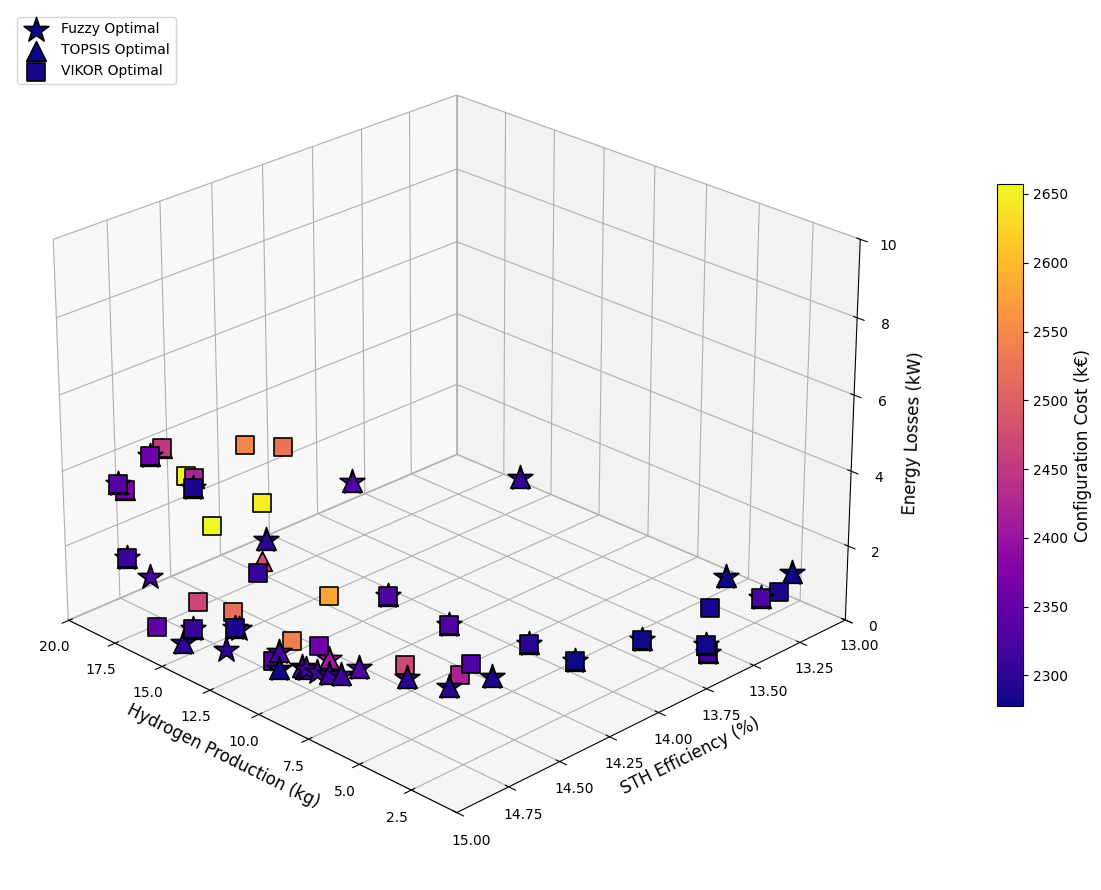

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

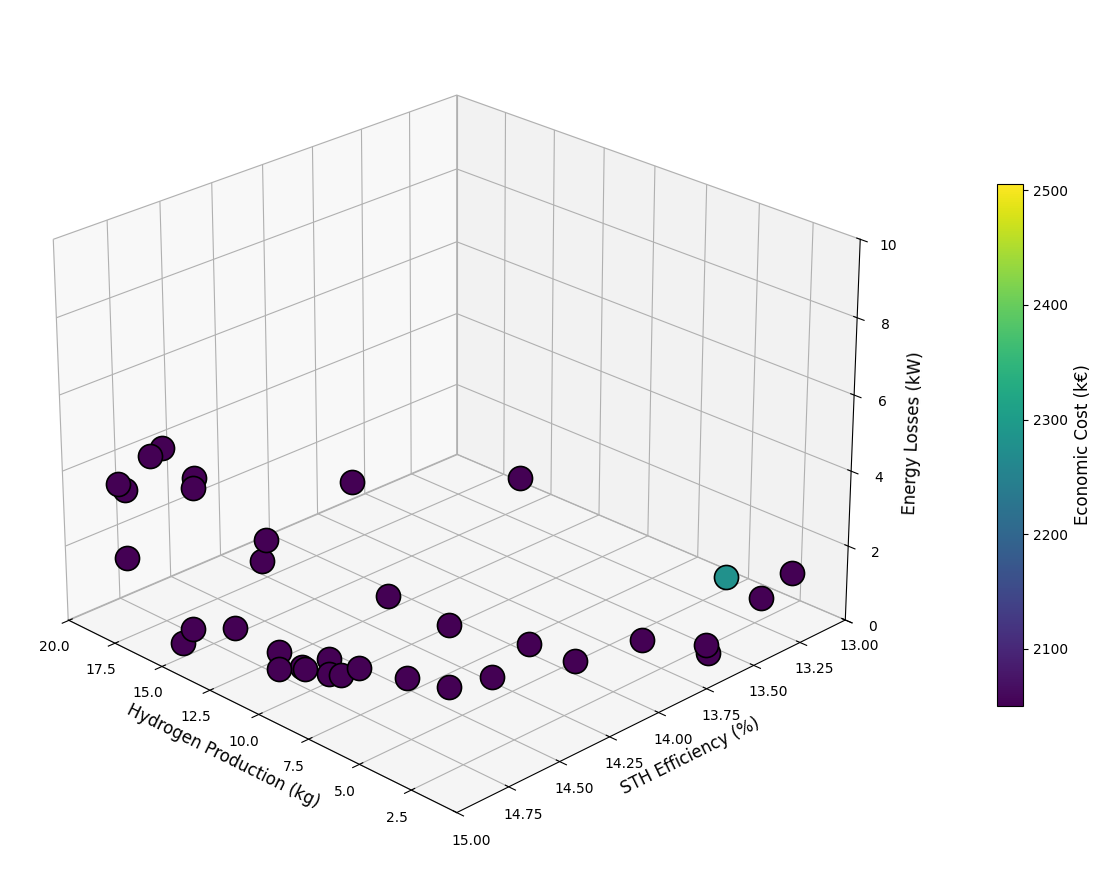

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
# --- Main VIKOR/Fuzzy/TOPSIS plot ---
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

labels_used = set()
all_costs = []
points_to_plot = []

for result in all_results_flex:
    if 'fuzzy_best_objectives' in result:
        f = np.array(result['fuzzy_best_objectives'])
        if not np.isnan(f).any():
            points_to_plot.append((-f[0], -f[1]*100, f[3]/1000, f[2]/1000, "Fuzzy Optimal", '*', 350))
    if 'topsis_best_objectives' in result:
        t = np.array(result['topsis_best_objectives'])
        if not np.isnan(t).any():
            points_to_plot.append((-t[0], -t[1]*100, t[3]/1000, t[2]/1000, "TOPSIS Optimal", '^', 200))
    if 'vikor_best_objectives' in result:
        v = np.array(result['vikor_best_objectives'])
        if not np.isnan(v).any():
            points_to_plot.append((-v[0], -v[1]*100, v[3]/1000, v[2]/1000, "VIKOR Optimal", 's', 150))

all_costs = np.array([p[3] for p in points_to_plot]) if points_to_plot else np.array([0])
vmin, vmax = np.min(all_costs), np.max(all_costs)

for (x, y, z, cost, label, marker, size) in points_to_plot:
    ax.scatter(x, y, z, c=[cost], cmap='plasma', vmin=vmin, vmax=vmax,
               marker=marker, s=size, edgecolor='black', linewidth=1.2,
               zorder=50, label=label if label not in labels_used else None)
    labels_used.add(label)

sc_for_colorbar = ax.scatter([], [], [], c=[], cmap='plasma', vmin=vmin, vmax=vmax)
cbar = plt.colorbar(sc_for_colorbar, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label("Configuration Cost (k€)", fontsize=12)

ax.set_xlabel("Hydrogen Production (kg)", fontsize=12)
ax.set_ylabel("STH Efficiency (%)", fontsize=12)
ax.set_zlabel("Energy Losses (kW)", fontsize=12)
ax.set_ylim(13, 15)  # <-- limit losses to 3 kW
ax.set_zlim(0, 10)  # <-- limit losses to 3 kW
ax.grid(True)
ax.legend(fontsize=10, loc="upper left")
ax.view_init(elev=25, azim=135)
plt.tight_layout()
plt.savefig("3D_Optimals_4_objectives.png", dpi=300, bbox_inches="tight")
plt.show()

from google.colab import files
files.download("3D_Optimals_4_objectives.png")


# --- Hybrid Optimal plot ---
fig2 = plt.figure(figsize=(12,9))
ax2 = fig2.add_subplot(111, projection='3d')

for result in all_results_flex:
    if 'hybrid_best_objectives' in result:
        h = np.array(result['hybrid_best_objectives'])
        if not np.isnan(h).any():
            ax2.scatter(-h[0], -h[1]*100, h[3]/1000,
                        c=h[2]/1000, cmap='viridis', s=300,
                        edgecolor='black', linewidth=1.2)

cbar2 = plt.colorbar(ax2.collections[0], ax=ax2, shrink=0.6, pad=0.1)
cbar2.set_label("Economic Cost (k€)", fontsize=12)

ax2.set_xlabel("Hydrogen Production (kg)", fontsize=12)
ax2.set_ylabel("STH Efficiency (%)", fontsize=12)
ax2.set_zlabel("Energy Losses (kW)", fontsize=12)
ax2.set_ylim(13, 15)  # <-- limit losses to 3 kW
ax2.set_zlim(0, 10)  # <-- limit losses to 3 kW
ax2.view_init(elev=25, azim=135)
plt.tight_layout()
plt.savefig("3D_Optimal_Solutions_4_objectives.png", dpi=300, bbox_inches="tight")
plt.show()

from google.colab import files
files.download("3D_Optimal_Solutions_4_objectives.png")

/tmp/ipython-input-3666613505.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


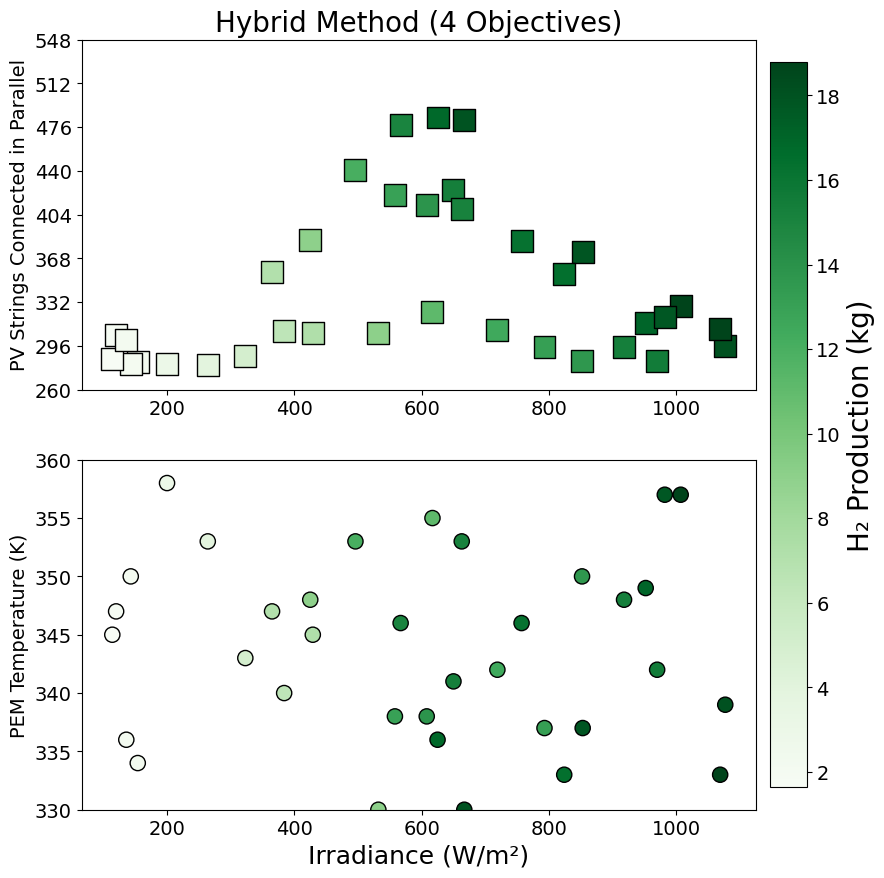

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# --- Extract only CRITIC-Hybrid data ---
vikor_PEM_T = np.array([res['vikor_best_solution'][4] if 'vikor_best_solution' in res else np.nan for res in all_results_flex])
vikor_values = np.array([res['vikor_best_solution'][1] if 'vikor_best_solution' in res else np.nan for res in all_results_flex])
vikor_objectives = np.array([-res['vikor_best_objectives'][0] if 'vikor_best_objectives' in res else np.nan for res in all_results_flex])
irradiance_values = np.array([res['irradiance'] for res in all_results_flex])

# Color scale based on CRITIC objectives
c_min = np.nanmin(vikor_objectives)
c_max = np.nanmax(vikor_objectives)

# --- Create figure: 2 rows x 1 column (PV strings / PEM temp) ---
fig, axes = plt.subplots(2, 1, figsize=(10, 10), gridspec_kw={'right': 0.85})

# PV Strings scatter
sc_pv = axes[0].scatter(
    irradiance_values, vikor_values,
    c=vikor_objectives, cmap='Greens',
    vmin=c_min, vmax=c_max,
    marker='s', s=250, edgecolors='black'
)
axes[0].set_title("Hybrid Method (4 Objectives)", fontsize=20)
axes[0].set_ylabel("PV Strings Connected in Parallel", fontsize=14)
axes[0].tick_params(axis='both', labelsize=14)
axes[0].set_yticks(np.arange(260, 570, 36))
axes[0].grid(False)

# PEM Temperature scatter
sc_pem = axes[1].scatter(
    irradiance_values, vikor_PEM_T,
    c=vikor_objectives, cmap='Greens',
    vmin=c_min, vmax=c_max,
    marker='o', s=120, edgecolors='black'
)
axes[1].set_ylim(330, 360)
axes[1].yaxis.set_major_locator(plt.MultipleLocator(5))
axes[1].set_xlabel("Irradiance (W/m²)", fontsize=18)
axes[1].set_ylabel("PEM Temperature (K)", fontsize=14)
axes[1].tick_params(axis='both', labelsize=14)
axes[1].grid(False)

# Colorbar only for CRITIC
cbar = fig.colorbar(sc_pem, ax=axes, fraction=0.05, pad=0.02)
cbar.set_label("H₂ Production (kg)", fontsize=20)
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
#plt.savefig("Scatter_Hybrid_4_objectives.png", dpi=300, bbox_inches='tight')
plt.show()

from google.colab import files
files.download("Scatter_Hybrid_4_objectives.png")

/tmp/ipython-input-390726926.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


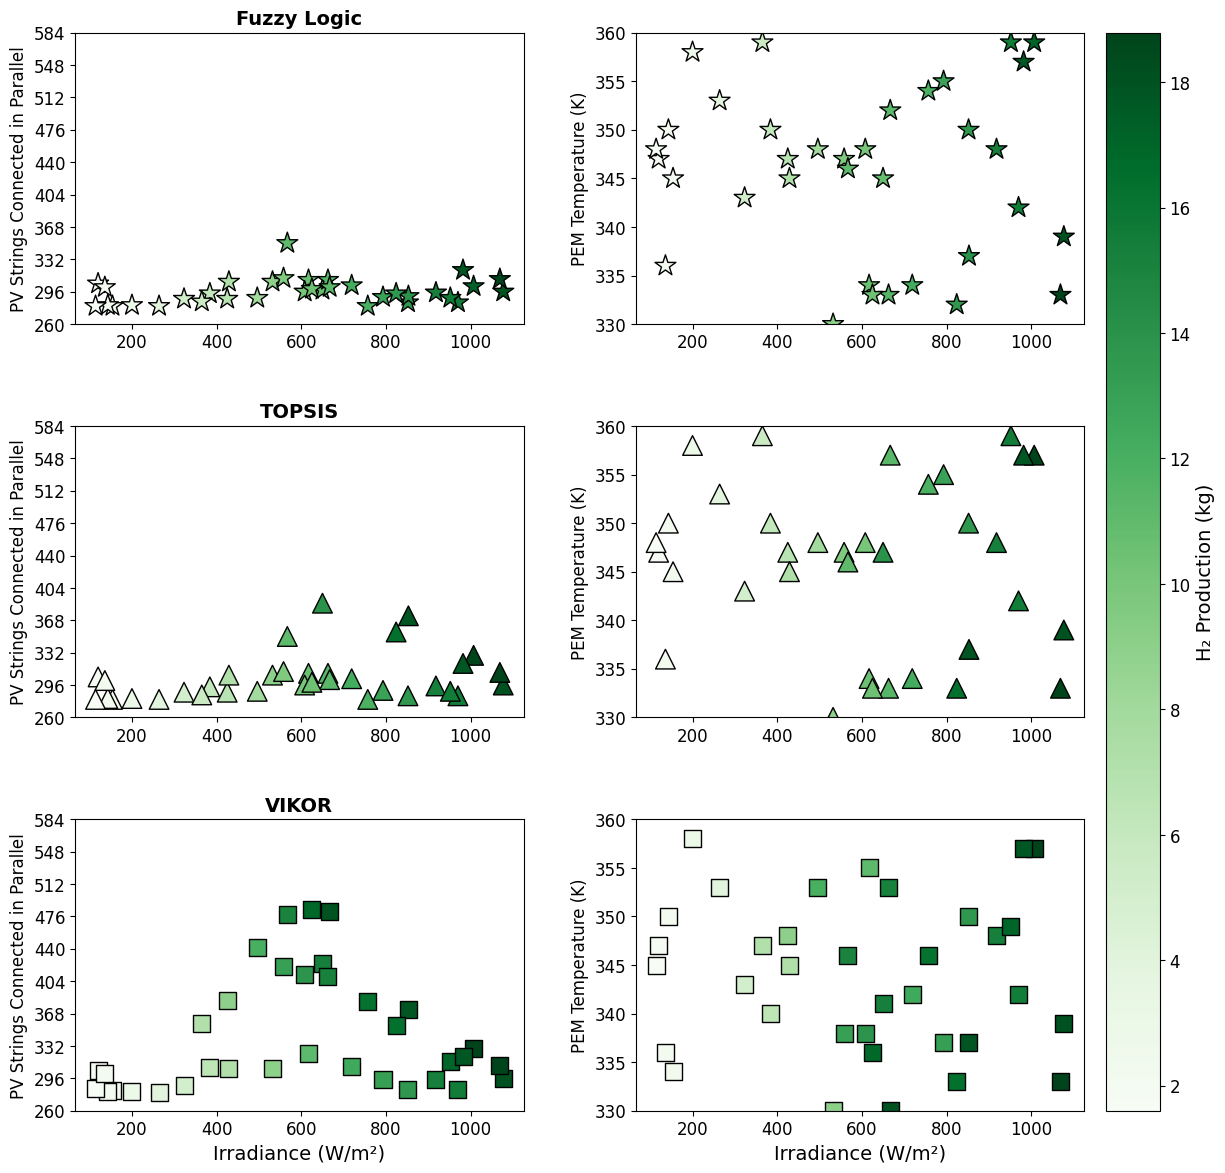

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [64]:
import matplotlib.pyplot as plt
import numpy as np

# --- Extract MCDA solutions ---
methods = ['fuzzy', 'topsis', 'vikor']
markers = {'fuzzy':'*', 'topsis':'^', 'vikor':'s'}
sizes = {'fuzzy':250, 'topsis':200, 'vikor':150}
titles = {'fuzzy':'Fuzzy Logic', 'topsis':'TOPSIS', 'vikor':'VIKOR'}

# Determine global color scale across all methods
all_objectives = []
for method in methods:
    all_objectives.extend([-res[f'{method}_best_objectives'][0] if f'{method}_best_objectives' in res else np.nan for res in all_results_flex])
all_objectives = np.array(all_objectives)
c_min, c_max = np.nanmin(all_objectives), np.nanmax(all_objectives)

# Create figure: 3 rows x 2 columns (PV strings / PEM temp)
fig, axes = plt.subplots(3, 2, figsize=(14, 14), gridspec_kw={'hspace':0.35, 'wspace':0.25})

for i, method in enumerate(methods):
    # Extract data
    PEM_T = np.array([res[f'{method}_best_solution'][4] if f'{method}_best_solution' in res else np.nan for res in all_results_flex])
    PV_values = np.array([res[f'{method}_best_solution'][1] if f'{method}_best_solution' in res else np.nan for res in all_results_flex])
    objectives = np.array([-res[f'{method}_best_objectives'][0] if f'{method}_best_objectives' in res else np.nan for res in all_results_flex])
    irradiance_values = np.array([res['irradiance'] for res in all_results_flex])

    # PV Strings scatter
    sc_pv = axes[i, 0].scatter(
        irradiance_values, PV_values,
        c=objectives, cmap='Greens',
        vmin=c_min, vmax=c_max,
        marker=markers[method], s=sizes[method], edgecolors='black'
    )
    axes[i, 0].set_ylabel("PV Strings Connected in Parallel", fontsize=12)
    axes[i, 0].set_title(titles[method], fontsize=14, fontweight='bold')
    axes[i, 0].tick_params(axis='both', labelsize=12)
    axes[i, 0].set_yticks(np.arange(260, 590, 36))
    axes[i, 0].grid(False)

    # PEM Temperature scatter
    sc_pem = axes[i, 1].scatter(
        irradiance_values, PEM_T,
        c=objectives, cmap='Greens',
        vmin=c_min, vmax=c_max,
        marker=markers[method], s=sizes[method], edgecolors='black'
    )
    axes[i, 1].set_ylabel("PEM Temperature (K)", fontsize=12)
    axes[i, 1].tick_params(axis='both', labelsize=12)
    axes[i, 1].set_ylim(330, 360)
    axes[i, 1].yaxis.set_major_locator(plt.MultipleLocator(5))
    axes[i, 1].grid(False)

# X-axis labels only on bottom row
axes[2, 0].set_xlabel("Irradiance (W/m²)", fontsize=14)
axes[2, 1].set_xlabel("Irradiance (W/m²)", fontsize=14)

# Colorbar for H2 production
cbar = fig.colorbar(sc_pem, ax=axes, fraction=0.05, pad=0.02)
cbar.set_label("H₂ Production (kg)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig("Scatter_MCDA_3methods_split_4_Obj.png", dpi=300, bbox_inches='tight')
plt.show()

from google.colab import files
files.download("Scatter_MCDA_3methods_split_4_Obj.png")





Correlation Matrix:
                   H2       STH      Cost      Loss  Irradiance
H2          1.000000  0.911707  0.465087  0.570509    0.932852
STH         0.911707  1.000000  0.304564  0.385097    0.916259
Cost        0.465087  0.304564  1.000000  0.318326    0.123966
Loss        0.570509  0.385097  0.318326  1.000000    0.491752
Irradiance  0.932852  0.916259  0.123966  0.491752    1.000000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

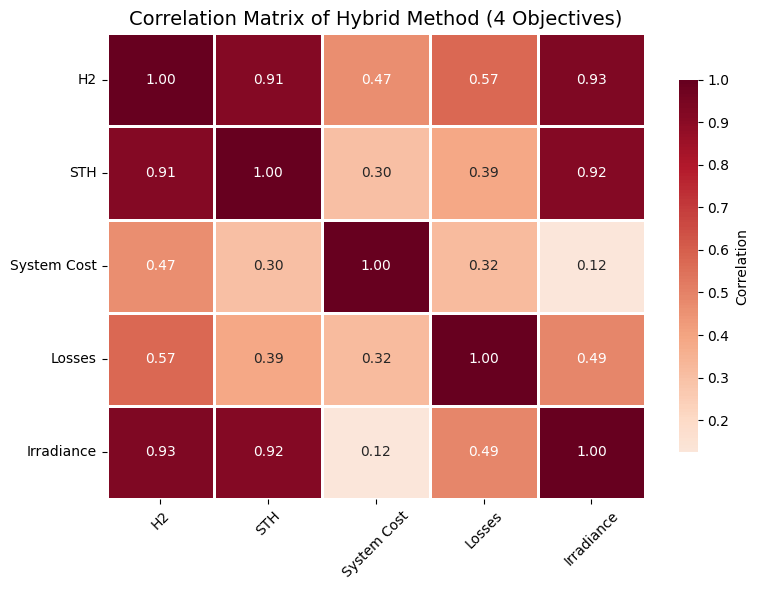

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Explained variance by each component (scaled): [6.63916573e-01 1.91708983e-01 1.29800388e-01 1.41231148e-02
 4.50941038e-04]
PCA Components (loadings):
          H2       STH  System Cost    Losses  Irradiance
0  0.541922  0.506192     0.251575  0.359449    0.507540
1 -0.019858 -0.230476     0.852868  0.283504   -0.372461
2 -0.114723 -0.294109    -0.377429  0.870461   -0.013571
3 -0.462558  0.774472    -0.032117  0.180698   -0.390577
4  0.691958  0.065905    -0.256596 -0.008264   -0.671522


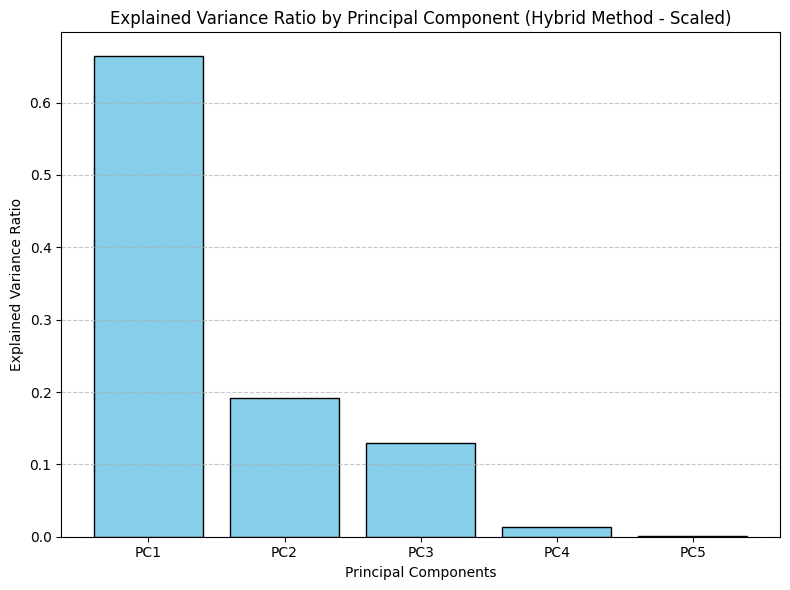

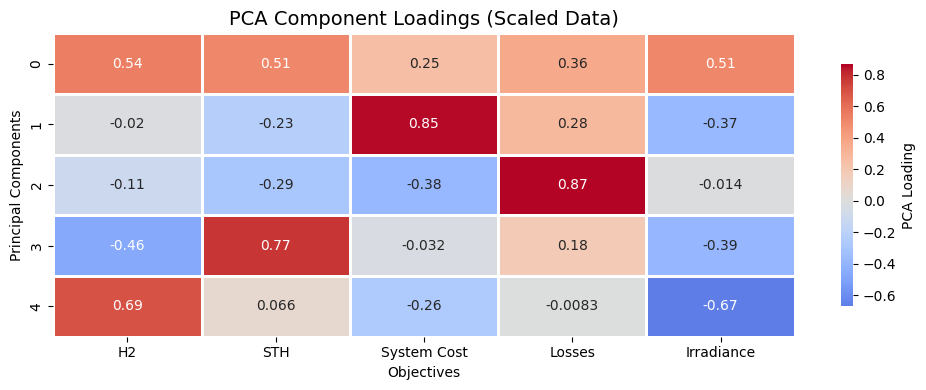

In [65]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

# ==================================================
# Extract Objective Performance for Aggregation (Copied from A2gQB7MjYHKk to resolve NameError)
# ==================================================

fuzzy_h2 = []; fuzzy_sth = []; fuzzy_losses = []; fuzzy_cost = []
topsis_h2 = []; topsis_sth = []; topsis_losses = []; topsis_cost = []
vikor_h2 = []; vikor_sth = []; vikor_losses = []; vikor_cost = []

for result in all_results_flex:

    if 'fuzzy_best_objectives' in result:
        obj = np.array(result['fuzzy_best_objectives'])
        fuzzy_h2.append(-obj[0]); fuzzy_sth.append(-obj[1])
        fuzzy_losses.append(obj[3]/1000); fuzzy_cost.append(obj[2]/1000)
    else:
        fuzzy_h2.append(np.nan); fuzzy_sth.append(np.nan)
        fuzzy_losses.append(np.nan); fuzzy_cost.append(np.nan)

    if 'topsis_best_objectives' in result:
        obj = np.array(result['topsis_best_objectives'])
        topsis_h2.append(-obj[0]); topsis_sth.append(-obj[1])
        topsis_losses.append(obj[3]/1000); topsis_cost.append(obj[2]/1000)
    else:
        topsis_h2.append(np.nan); topsis_sth.append(np.nan)
        topsis_losses.append(np.nan); topsis_cost.append(np.nan)

    if 'vikor_best_objectives' in result:
        obj = np.array(result['vikor_best_objectives'])
        vikor_h2.append(-obj[0]); vikor_sth.append(-obj[1])
        vikor_losses.append(obj[3]/1000); vikor_cost.append(obj[2]/1000)
    else:
        vikor_h2.append(np.nan); vikor_sth.append(np.nan)
        vikor_losses.append(np.nan); vikor_cost.append(np.nan)

# Convert
fuzzy_h2 = np.array(fuzzy_h2); fuzzy_sth = np.array(fuzzy_sth)
fuzzy_losses = np.array(fuzzy_losses); fuzzy_cost = np.array(fuzzy_cost)

topsis_h2 = np.array(topsis_h2); topsis_sth = np.array(topsis_sth)
topsis_losses = np.array(topsis_losses); topsis_cost = np.array(topsis_cost)

vikor_h2 = np.array(vikor_h2); vikor_sth = np.array(vikor_sth)
vikor_losses = np.array(vikor_losses); vikor_cost = np.array(vikor_cost)

# Define irradiance_values (Copied from pwD_lfw2JEtp to resolve NameError)
irradiance_values = np.array([res['irradiance'] for res in all_results_flex])

# -----------------------------
# Prepare DataFrame
# -----------------------------
hybrid_df = pd.DataFrame({
    'H2': vikor_h2,
    'STH': vikor_sth,
    'Cost': vikor_cost,
    'Loss': vikor_losses,
    'Irradiance': irradiance_values
})

# Objective names for plots
objective_names = ['H2', 'STH', 'System Cost', 'Losses', 'Irradiance']

# -----------------------------
# Correlation Matrix
# -----------------------------
correlation_matrix = hybrid_df.corr()
print("Correlation Matrix:\n", correlation_matrix)

# Save correlation matrix as CSV
correlation_matrix.to_csv("correlation_matrix_hybrid_4Obj.csv")
files.download("correlation_matrix_hybrid_4Obj.csv")

# Plot correlation matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',     # Diverging colormap for positive/negative correlation
    center=0,
    linewidths=0.8,
    cbar_kws={"shrink": 0.8, "label": "Correlation"}
)
plt.title('Correlation Matrix of Hybrid Method (4 Objectives)', fontsize=14)
plt.xticks(ticks=np.arange(len(objective_names)) + 0.5, labels=objective_names, rotation=45)
plt.yticks(ticks=np.arange(len(objective_names)) + 0.5, labels=objective_names, rotation=0)
plt.tight_layout()
plt.savefig("Correlation_Matrix_Hybrid_4Obj_Improved.png", dpi=300)
plt.show()
files.download("Correlation_Matrix_Hybrid_4Obj_Improved.png")

# -----------------------------
# Standardize data for PCA
# -----------------------------
scaler = StandardScaler()
hybrid_scaled = scaler.fit_transform(hybrid_df)

# -----------------------------
# PCA (Principal Component Analysis)
# -----------------------------
pca = PCA()
pca.fit(hybrid_scaled)
explained = pca.explained_variance_ratio_
print("Explained variance by each component (scaled):", explained)

# PCA component loadings (contribution of each objective)
components = pd.DataFrame(pca.components_, columns=objective_names)
print("PCA Components (loadings):\n", components)

# -----------------------------
# Plot explained variance ratio
# -----------------------------
plt.figure(figsize=(8, 6))
plt.bar(range(1, len(explained) + 1), explained, color='skyblue', edgecolor='black')
plt.xticks(range(1, len(explained) + 1), [f'PC{i}' for i in range(1, len(explained)+1)])
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Explained Variance Ratio by Principal Component (Hybrid Method - Scaled)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# -----------------------------
# Plot PCA loadings as a heatmap
# -----------------------------
plt.figure(figsize=(10,4))
sns.heatmap(
    components,
    annot=True,
    cmap='coolwarm',
    center=0,
    linewidths=0.8,
    cbar_kws={"shrink":0.8, "label":"PCA Loading"}
)
plt.title('PCA Component Loadings (Scaled Data)', fontsize=14)
plt.xlabel('Objectives')
plt.ylabel('Principal Components')
plt.tight_layout()
plt.show()

In [66]:
# ==================================================
# Extract Objective Performance for Aggregation
# ==================================================

fuzzy_h2 = []; fuzzy_sth = []; fuzzy_losses = []; fuzzy_cost = []
topsis_h2 = []; topsis_sth = []; topsis_losses = []; topsis_cost = []
vikor_h2 = []; vikor_sth = []; vikor_losses = []; vikor_cost = []

for result in all_results_flex:

    if 'fuzzy_best_objectives' in result:
        obj = np.array(result['fuzzy_best_objectives'])
        fuzzy_h2.append(-obj[0]); fuzzy_sth.append(-obj[1])
        fuzzy_losses.append(obj[3]/1000); fuzzy_cost.append(obj[2]/1000)
    else:
        fuzzy_h2.append(np.nan); fuzzy_sth.append(np.nan)
        fuzzy_losses.append(np.nan); fuzzy_cost.append(np.nan)

    if 'topsis_best_objectives' in result:
        obj = np.array(result['topsis_best_objectives'])
        topsis_h2.append(-obj[0]); topsis_sth.append(-obj[1])
        topsis_losses.append(obj[3]/1000); topsis_cost.append(obj[2]/1000)
    else:
        topsis_h2.append(np.nan); topsis_sth.append(np.nan)
        topsis_losses.append(np.nan); topsis_cost.append(np.nan)

    if 'vikor_best_objectives' in result:
        obj = np.array(result['vikor_best_objectives'])
        vikor_h2.append(-obj[0]); vikor_sth.append(-obj[1])
        vikor_losses.append(obj[3]/1000); vikor_cost.append(obj[2]/1000)
    else:
        vikor_h2.append(np.nan); vikor_sth.append(np.nan)
        vikor_losses.append(np.nan); vikor_cost.append(np.nan)

# Convert
fuzzy_h2 = np.array(fuzzy_h2); fuzzy_sth = np.array(fuzzy_sth)
fuzzy_losses = np.array(fuzzy_losses); fuzzy_cost = np.array(fuzzy_cost)

topsis_h2 = np.array(topsis_h2); topsis_sth = np.array(topsis_sth)
topsis_losses = np.array(topsis_losses); topsis_cost = np.array(topsis_cost)

vikor_h2 = np.array(vikor_h2); vikor_sth = np.array(vikor_sth)
vikor_losses = np.array(vikor_losses); vikor_cost = np.array(vikor_cost)


# The calculation of critic_best_objectives has been moved to the MCDA loop in r0fG0GgHyTrY
# This section now only extracts the results.

critic_h2 = []
critic_sth = []
critic_losses = []
critic_cost = []

for result in all_results_flex:
    if 'critic_best_objectives' in result:
        obj = np.array(result['critic_best_objectives'])
        critic_h2.append(-obj[0])
        critic_sth.append(-obj[1])
        critic_losses.append(obj[3]/1000)
        critic_cost.append(obj[2]/1000)
    else:
        critic_h2.append(np.nan)
        critic_sth.append(np.nan)
        critic_losses.append(np.nan)
        critic_cost.append(np.nan)


# ==================================================
# Performance Summary
# ==================================================
def print_summary(name, h2, sth, losses, cost):
    print(f"\n=== {name} ===")
    print(f"Total H₂ Production: {np.nansum(h2):.4f} kg")
    print(f"Average STH Efficiency: {np.nanmean(sth):.4f} %")
    print(f"Total Energy Losses: {np.nansum(losses):.4f} kW")
    print(f"Maximum Economic Cost: {np.nanmax(cost):.2f} k€")

print_summary("Fuzzy", fuzzy_h2, fuzzy_sth, fuzzy_losses, fuzzy_cost)
print_summary("TOPSIS", topsis_h2, topsis_sth, topsis_losses, topsis_cost)
print_summary("VIKOR", vikor_h2, vikor_sth, vikor_losses, vikor_cost)
print_summary("CRITIC-Hybrid", critic_h2, critic_sth, critic_losses, critic_cost)


=== Fuzzy ===
Total H₂ Production: 346.3306 kg
Average STH Efficiency: 0.1440 %
Total Energy Losses: 42.0075 kW
Maximum Economic Cost: 2408.00 k€

=== TOPSIS ===
Total H₂ Production: 357.7016 kg
Average STH Efficiency: 0.1440 %
Total Energy Losses: 53.5277 kW
Maximum Economic Cost: 2476.82 k€

=== VIKOR ===
Total H₂ Production: 402.0212 kg
Average STH Efficiency: 0.1440 %
Total Energy Losses: 61.0651 kW
Maximum Economic Cost: 2657.24 k€

=== CRITIC-Hybrid ===
Total H₂ Production: 346.3306 kg
Average STH Efficiency: 0.1440 %
Total Energy Losses: 42.0075 kW
Maximum Economic Cost: 2408.00 k€



🎯 CRITIC average objective weights (H2, STH, LOSS):
[0.591  0.1004 0.3086]


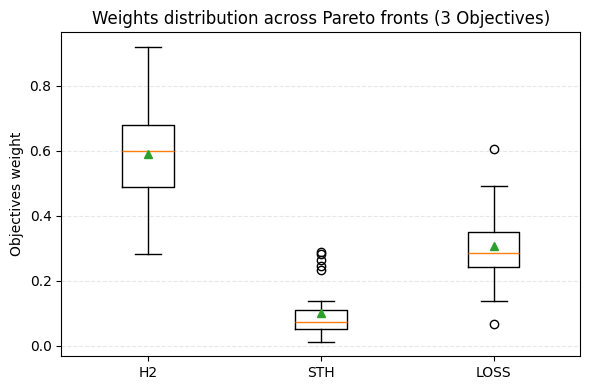

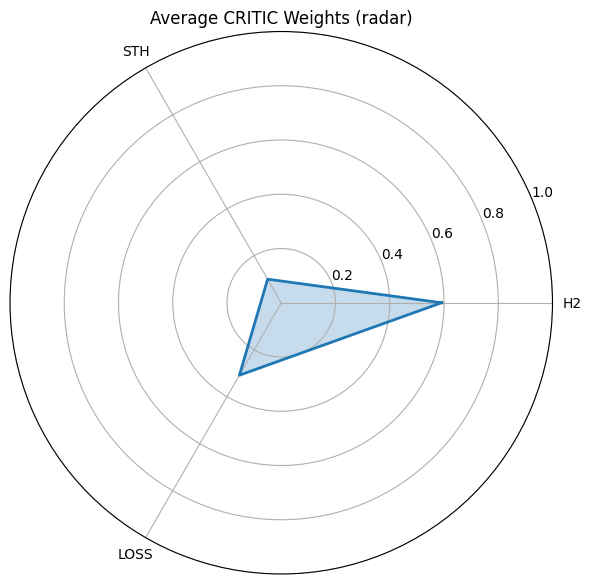

In [67]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import pandas as pd

# Load results from saved JSON file
# with open("nsga2_results.json", "r") as f:
#     all_results_flex = json.load(f)

PLOT_WEIGHTS = True
SAVE_FIG_PREFIX = "mcda_weights"
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# -----------------------------
# Constants / Objective indices
OBJ_H2 = 0
OBJ_STH = 1
OBJ_LOSS = 3    # skip cost
M = 3          # only 3 objectives now
EPS = 1e-12
VIKOR_V = 0.5
PLOT_WEIGHTS = True
SAVE_FIG_PREFIX = "mcda_weights_3obj"

# -----------------------------
def to_maximize_array(arr):
    a = np.array(arr, dtype=float)
    a_max = np.empty(M)
    a_max[0] = -a[OBJ_H2]   # H2
    a_max[1] = -a[OBJ_STH]  # STH
    a_max[2] = -a[OBJ_LOSS] # LOSS
    return a_max

# -----------------------------
# Build global scaling
all_maximize = [np.vstack([to_maximize_array(pf) for pf in np.array(r['pareto_front'], dtype=float)])
                for r in all_results_flex if 'pareto_front' in r and len(r['pareto_front'])>0]

if not all_maximize:
    raise RuntimeError("No Pareto fronts found.")

all_maximize = np.vstack(all_maximize)
global_min = np.nanmin(all_maximize, axis=0)
global_max = np.nanmax(all_maximize, axis=0)
global_range = global_max - global_min
global_range[global_range==0] = EPS

def prepare_objectives_global(pareto_front):
    X = np.array([to_maximize_array(pf) for pf in pareto_front])
    X_norm = (X - global_min) / global_range
    X_norm = np.clip(X_norm, 0.0, 1.0)
    return X_norm

def critic_weights(X_norm):
    std = np.nanstd(X_norm, axis=0, ddof=0)
    corr = np.corrcoef(X_norm, rowvar=False)
    if corr.shape != (M,M) or np.isnan(corr).any():
        corr = np.eye(M)
    conflict = np.sum(1.0 - corr, axis=0)
    C = std * conflict
    if np.allclose(C,0):
        return np.ones(M)/M
    return C / (np.sum(C)+EPS)

# -----------------------------
# MCDA methods using CRITIC weights
def fuzzy_score(X_norm, weights):
    scores = X_norm.dot(weights)
    order = np.argsort(-scores)
    return scores, order

def topsis_rank(X_norm, weights):
    V = X_norm * np.asarray(weights)
    ideal = np.max(V, axis=0)
    nadir = np.min(V, axis=0)
    D_plus = np.linalg.norm(V - ideal, axis=1)
    D_minus = np.linalg.norm(V - nadir, axis=1)
    C = D_minus / (D_plus + D_minus + EPS)
    order = np.argsort(-C)
    return C, order

def vikor_rank(X_norm, weights, v=VIKOR_V):
    W = np.asarray(weights)
    ideal = np.max(X_norm, axis=0)
    nadir = np.min(X_norm, axis=0)
    diff = (ideal - X_norm) / (ideal - nadir + EPS)
    S = np.sum(W*diff, axis=1)
    R = np.max(W*diff, axis=1)
    S_range = np.ptp(S) if np.ptp(S)!=0 else EPS
    R_range = np.ptp(R) if np.ptp(R)!=0 else EPS
    Q = v*(S-np.min(S))/S_range + (1-v)*(R-np.min(R))/R_range
    order = np.argsort(Q)
    return Q, order

# -----------------------------
critic_weights_all = []

for r in all_results_flex:
    pf = r.get('pareto_front', None)
    if pf is None or len(pf)==0:
        continue
    X_norm = prepare_objectives_global(pf)

    # CRITIC weights
    w = critic_weights(X_norm)
    r['critic_weights'] = w
    critic_weights_all.append(w)

    # MCDA selections
    fuzzy_scores, fuzzy_order = fuzzy_score(X_norm, w)
    topsis_scores, topsis_order = topsis_rank(X_norm, w)
    vikor_scores, vikor_order = vikor_rank(X_norm, w)

    r['fuzzy_best_index'] = int(fuzzy_order[0])
    r['topsis_best_index'] = int(topsis_order[0])
    r['vikor_best_index'] = int(vikor_order[0])
    r['critic_best_index'] = int(np.argmax(X_norm.dot(w)))

    r['fuzzy_best_solution'] = r.get('pareto_solutions',[None]*len(pf))[r['fuzzy_best_index']]
    r['topsis_best_solution'] = r.get('pareto_solutions',[None]*len(pf))[r['topsis_best_index']]
    r['vikor_best_solution'] = r.get('pareto_solutions',[None]*len(pf))[r['vikor_best_index']]
    r['critic_best_solution'] = r.get('pareto_solutions',[None]*len(pf))[r['critic_best_index']]

    r['fuzzy_best_objectives'] = pf[r['fuzzy_best_index']]
    r['topsis_best_objectives'] = pf[r['topsis_best_index']]
    r['vikor_best_objectives'] = pf[r['vikor_best_index']]
    r['critic_best_objectives'] = pf[r['critic_best_index']]

# -----------------------------
# Final average CRITIC weights
average_weights = np.nanmean(np.array(critic_weights_all), axis=0)
print("\n🎯 CRITIC average objective weights (H2, STH, LOSS):")
print(np.round(average_weights,4))

# -----------------------------
# Optional: plot boxplot & radar
if PLOT_WEIGHTS:
    labels = ['H2','STH','LOSS']

    # Boxplot
    plt.figure(figsize=(6,4))
    plt.boxplot(np.array(critic_weights_all), tick_labels=labels, showmeans=True)
    plt.title('Weights distribution across Pareto fronts (3 Objectives)')
    plt.ylabel('Objectives weight')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{SAVE_FIG_PREFIX}_boxplot.png", dpi=150)
    plt.show()

    # Radar
    radar_vals = np.concatenate([average_weights, average_weights[:1]])
    angles = np.linspace(0, 2*np.pi, len(average_weights)+1, endpoint=True)
    fig, ax = plt.subplots(subplot_kw=dict(polar=True), figsize=(6,6))
    ax.plot(angles, radar_vals, linewidth=2)
    ax.fill(angles, radar_vals, alpha=0.25)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    ax.set_ylim(0, np.max([1.0, np.max(average_weights)*1.1]))
    ax.set_title('Average CRITIC Weights (radar)')
    plt.tight_layout()
    plt.savefig(f"{SAVE_FIG_PREFIX}_radar.png", dpi=150)
    plt.show()

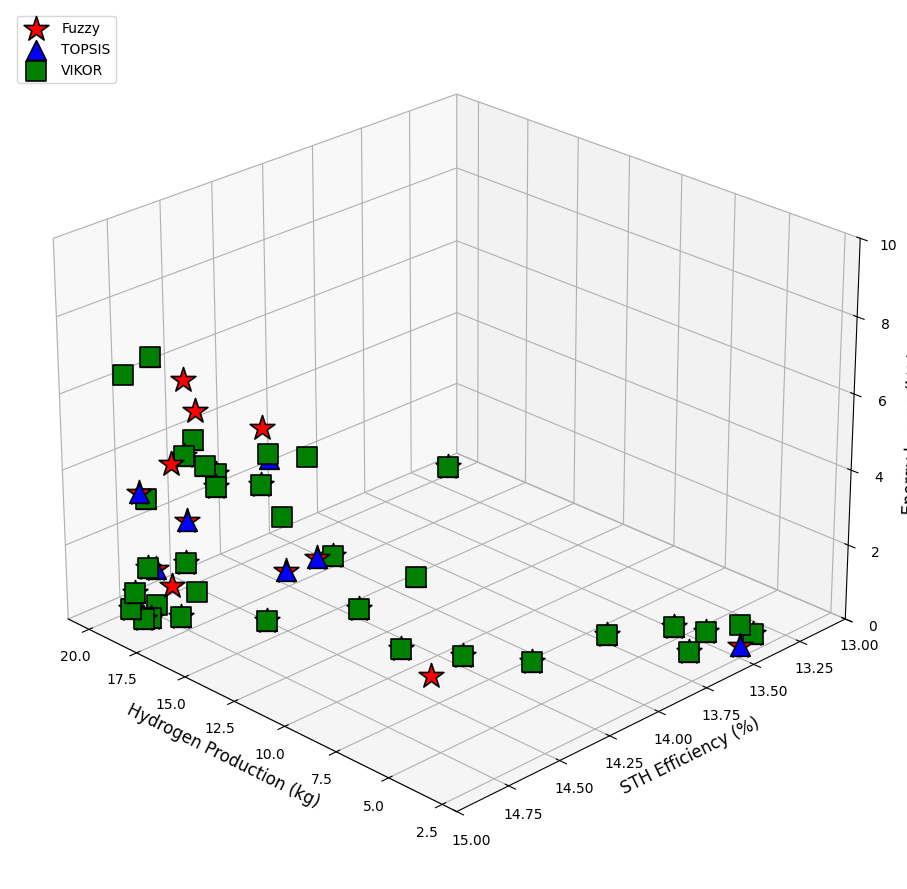

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# ===========================
# 1. 3D plot for all optimals
# ===========================
points_to_plot = []

for result in all_results_flex:
    if 'fuzzy_best_objectives' in result:
        f = np.array(result['fuzzy_best_objectives'])
        if not np.isnan(f).any():
            points_to_plot.append((-f[0], -f[1]*100, f[3]/1000, "Fuzzy", '*', 'red', 350))
    if 'topsis_best_objectives' in result:
        t = np.array(result['topsis_best_objectives'])
        if not np.isnan(t).any():
            points_to_plot.append((-t[0], -t[1]*100, t[3]/1000, "TOPSIS", '^', 'blue', 200))
    if 'vikor_best_objectives' in result:
        v = np.array(result['vikor_best_objectives'])
        if not np.isnan(v).any():
            points_to_plot.append((-v[0], -v[1]*100, v[3]/1000, "VIKOR", 's', 'green', 200))


# Plot All Methods
fig1 = plt.figure(figsize=(12, 9))
ax1 = fig1.add_subplot(111, projection='3d')
labels_used = set()

for (x, y, z, label, marker, color, size) in points_to_plot:
    ax1.scatter(x, y, z, marker=marker, color=color, s=size,
                edgecolor='black', linewidth=1.2,
                label=label if label not in labels_used else None)
    labels_used.add(label)

# Axes
ax1.set_xlabel("Hydrogen Production (kg)", fontsize=12)
ax1.set_ylabel("STH Efficiency (%)", fontsize=12)
ax1.set_zlabel("Energy Losses (kW)", fontsize=12)
ax1.set_ylim(13, 15)
ax1.set_zlim(0, 10)



# View angle
ax1.view_init(elev=25, azim=135)
ax1.legend(fontsize=10, loc="upper left")
plt.tight_layout()
plt.savefig("3D_Optimals_All_Methods.png", dpi=300, bbox_inches="tight")
plt.show()
files.download("3D_Optimals_All_Methods.png")


/tmp/ipython-input-1738407532.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


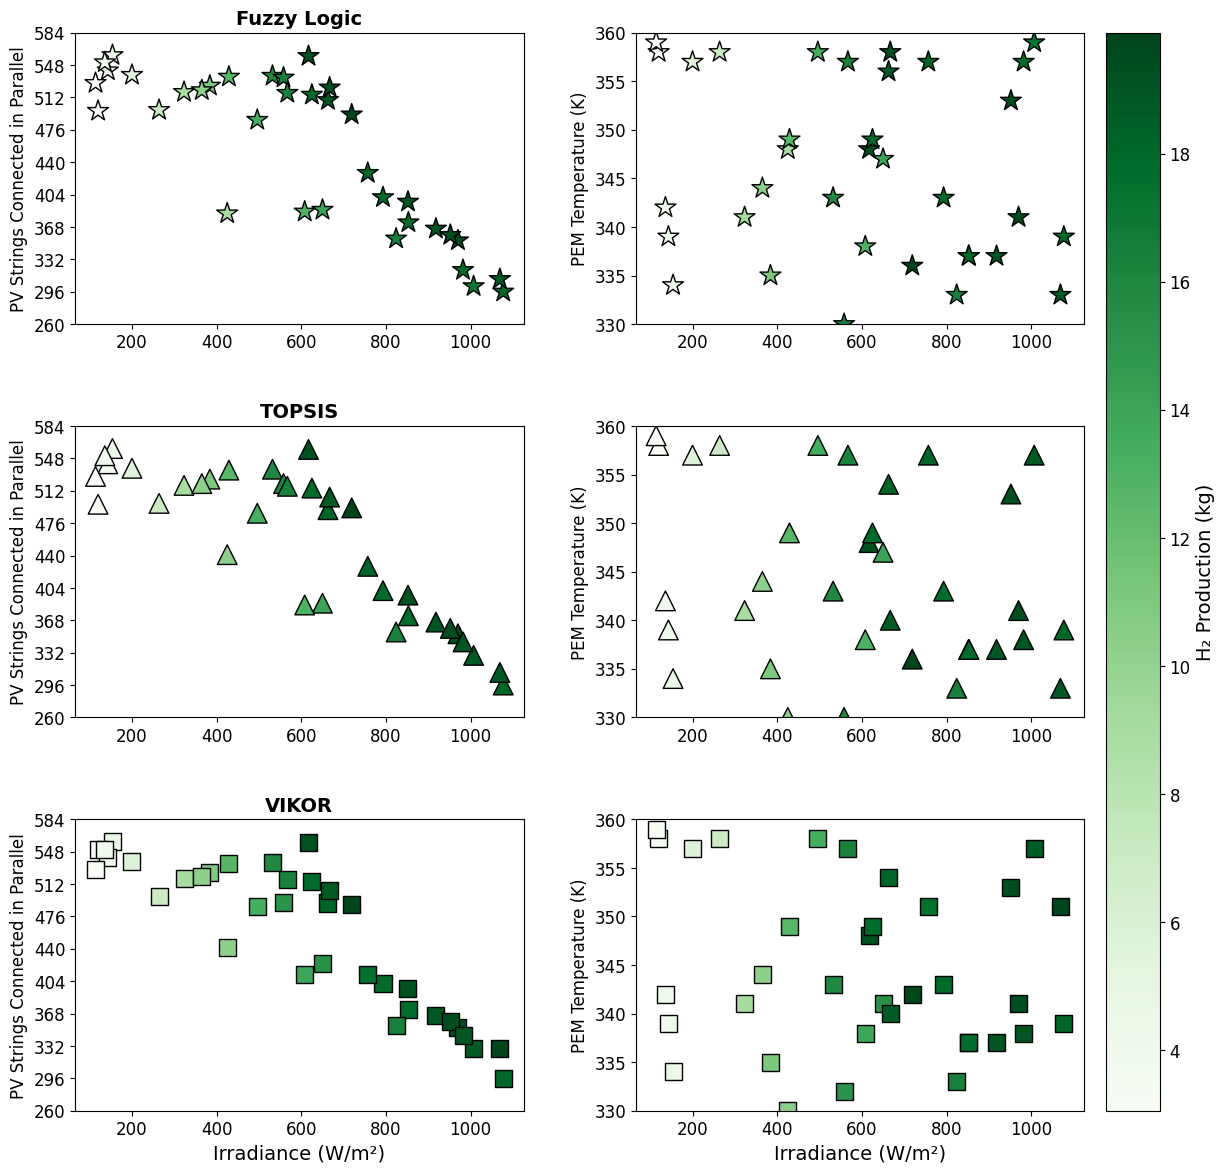

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# --- Extract MCDA solutions ---
methods = ['fuzzy', 'topsis', 'vikor']
markers = {'fuzzy':'*', 'topsis':'^', 'vikor':'s'}
sizes = {'fuzzy':250, 'topsis':200, 'vikor':150}
titles = {'fuzzy':'Fuzzy Logic', 'topsis':'TOPSIS', 'vikor':'VIKOR'}

# Determine global color scale across all methods
all_objectives = []
for method in methods:
    all_objectives.extend([-res[f'{method}_best_objectives'][0] if f'{method}_best_objectives' in res else np.nan for res in all_results_flex])
all_objectives = np.array(all_objectives)
c_min, c_max = np.nanmin(all_objectives), np.nanmax(all_objectives)

# Create figure: 3 rows x 2 columns (PV strings / PEM temp)
fig, axes = plt.subplots(3, 2, figsize=(14, 14), gridspec_kw={'hspace':0.35, 'wspace':0.25})

for i, method in enumerate(methods):
    # Extract data
    PEM_T = np.array([res[f'{method}_best_solution'][4] if f'{method}_best_solution' in res else np.nan for res in all_results_flex])
    PV_values = np.array([res[f'{method}_best_solution'][1] if f'{method}_best_solution' in res else np.nan for res in all_results_flex])
    objectives = np.array([-res[f'{method}_best_objectives'][0] if f'{method}_best_objectives' in res else np.nan for res in all_results_flex])
    irradiance_values = np.array([res['irradiance'] for res in all_results_flex])

    # PV Strings scatter
    sc_pv = axes[i, 0].scatter(
        irradiance_values, PV_values,
        c=objectives, cmap='Greens',
        vmin=c_min, vmax=c_max,
        marker=markers[method], s=sizes[method], edgecolors='black'
    )
    axes[i, 0].set_ylabel("PV Strings Connected in Parallel", fontsize=12)
    axes[i, 0].set_title(titles[method], fontsize=14, fontweight='bold')
    axes[i, 0].tick_params(axis='both', labelsize=12)
    axes[i, 0].set_yticks(np.arange(260, 590, 36))
    axes[i, 0].grid(False)

    # PEM Temperature scatter
    sc_pem = axes[i, 1].scatter(
        irradiance_values, PEM_T,
        c=objectives, cmap='Greens',
        vmin=c_min, vmax=c_max,
        marker=markers[method], s=sizes[method], edgecolors='black'
    )
    axes[i, 1].set_ylabel("PEM Temperature (K)", fontsize=12)
    axes[i, 1].tick_params(axis='both', labelsize=12)
    axes[i, 1].set_ylim(330, 360)
    axes[i, 1].yaxis.set_major_locator(plt.MultipleLocator(5))
    axes[i, 1].grid(False)

# X-axis labels only on bottom row
axes[2, 0].set_xlabel("Irradiance (W/m²)", fontsize=14)
axes[2, 1].set_xlabel("Irradiance (W/m²)", fontsize=14)

# Colorbar for H2 production
cbar = fig.colorbar(sc_pem, ax=axes, fraction=0.05, pad=0.02)
cbar.set_label("H₂ Production (kg)", fontsize=14)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.savefig("Scatter_MCDA_3methods_split.png", dpi=300, bbox_inches='tight')
plt.show()

from google.colab import files
files.download("Scatter_MCDA_3methods_split.png")

Correlation Matrix:
                   H2       STH      Loss  Irradiance
H2          1.000000  0.911707  0.570509    0.932852
STH         0.911707  1.000000  0.385097    0.916259
Loss        0.570509  0.385097  1.000000    0.491752
Irradiance  0.932852  0.916259  0.491752    1.000000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

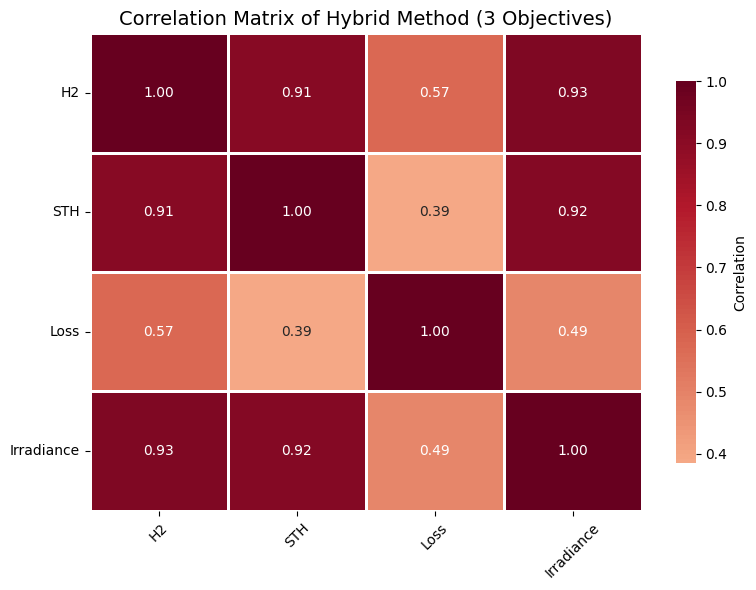

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Explained variance by each component (scaled): [0.79107317 0.1751991  0.01896055 0.01476719]
PCA Components (loadings):
          H2       STH      Loss  Irradiance
0  0.549336  0.524655  0.361063    0.540926
1 -0.077261 -0.348652  0.913832   -0.193347
2  0.046241 -0.698022 -0.113121    0.705572
3  0.830736 -0.340507 -0.147472   -0.414952


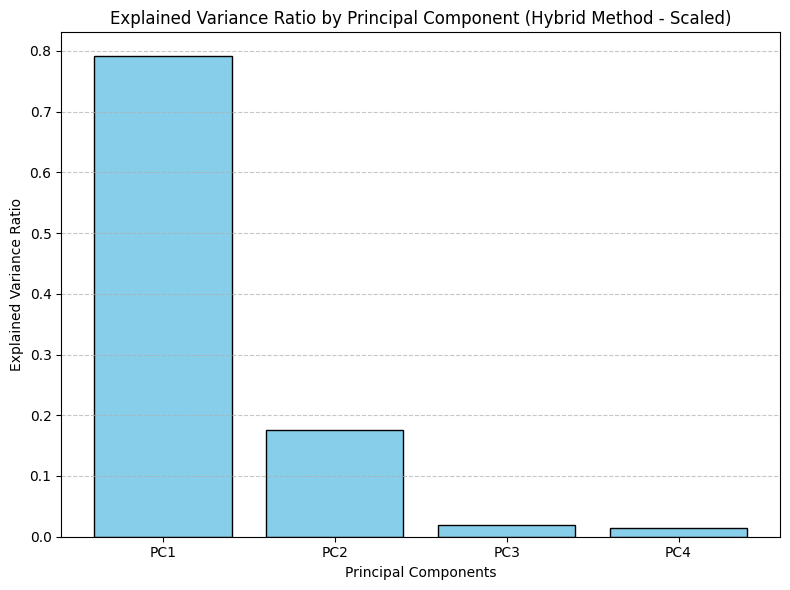

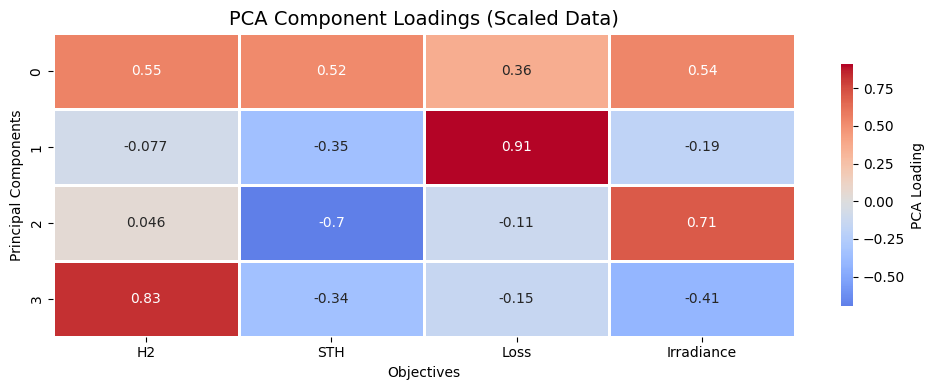

In [70]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import files

# -----------------------------
# Prepare DataFrame
# -----------------------------
hybrid_df = pd.DataFrame({
    'H2': vikor_h2,
    'STH': vikor_sth,
    #'Cost': critic_cost,
    'Loss': vikor_losses,
    'Irradiance': irradiance_values
})

# Objective names for plots
objective_names = ['H2', 'STH', 'Loss', 'Irradiance']

# -----------------------------
# Correlation Matrix
# -----------------------------
correlation_matrix = hybrid_df.corr()
print("Correlation Matrix:\n", correlation_matrix)

# Save correlation matrix as CSV
correlation_matrix.to_csv("correlation_matrix_hybrid_4Obj.csv")
files.download("correlation_matrix_hybrid_4Obj.csv")

# Plot correlation matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',     # Diverging colormap for positive/negative correlation
    center=0,
    linewidths=0.8,
    cbar_kws={"shrink": 0.8, "label": "Correlation"}
)
plt.title('Correlation Matrix of Hybrid Method (3 Objectives)', fontsize=14)
plt.xticks(ticks=np.arange(len(objective_names)) + 0.5, labels=objective_names, rotation=45)
plt.yticks(ticks=np.arange(len(objective_names)) + 0.5, labels=objective_names, rotation=0)
plt.tight_layout()
plt.savefig("Correlation_Matrix_Hybrid_3_Obj_Improved.png", dpi=300)
plt.show()
files.download("Correlation_Matrix_Hybrid_3_Obj_Improved.png")

# -----------------------------
# Standardize data for PCA
# -----------------------------
scaler = StandardScaler()
hybrid_scaled = scaler.fit_transform(hybrid_df)

# -----------------------------
# PCA (Principal Component Analysis)
# -----------------------------
pca = PCA()
pca.fit(hybrid_scaled)
explained = pca.explained_variance_ratio_
print("Explained variance by each component (scaled):", explained)

# PCA component loadings (contribution of each objective)
components = pd.DataFrame(pca.components_, columns=objective_names)
print("PCA Components (loadings):\n", components)

# -----------------------------
# Plot explained variance ratio
# -----------------------------
plt.figure(figsize=(8, 6))
plt.bar(range(1, len(explained) + 1), explained, color='skyblue', edgecolor='black')
plt.xticks(range(1, len(explained) + 1), [f'PC{i}' for i in range(1, len(explained)+1)])
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.title('Explained Variance Ratio by Principal Component (Hybrid Method - Scaled)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# -----------------------------
# Plot PCA loadings as a heatmap
# -----------------------------
plt.figure(figsize=(10,4))
sns.heatmap(
    components,
    annot=True,
    cmap='coolwarm',
    center=0,
    linewidths=0.8,
    cbar_kws={"shrink":0.8, "label":"PCA Loading"}
)
plt.title('PCA Component Loadings (Scaled Data)', fontsize=14)
plt.xlabel('Objectives')
plt.ylabel('Principal Components')
plt.tight_layout()
plt.show()

In [71]:

# ==================================================
# Extract Objective Performance for Aggregation
# ==================================================

fuzzy_h2 = []; fuzzy_sth = []; fuzzy_losses = []; fuzzy_cost = []
topsis_h2 = []; topsis_sth = []; topsis_losses = []; topsis_cost = []
vikor_h2 = []; vikor_sth = []; vikor_losses = []; vikor_cost = []

for result in all_results_flex:

    if 'fuzzy_best_objectives' in result:
        obj = np.array(result['fuzzy_best_objectives'])
        fuzzy_h2.append(-obj[0]); fuzzy_sth.append(-obj[1])
        fuzzy_losses.append(obj[3]/1000); fuzzy_cost.append(obj[2]/1000)
    else:
        fuzzy_h2.append(np.nan); fuzzy_sth.append(np.nan)
        fuzzy_losses.append(np.nan); fuzzy_cost.append(np.nan)

    if 'topsis_best_objectives' in result:
        obj = np.array(result['topsis_best_objectives'])
        topsis_h2.append(-obj[0]); topsis_sth.append(-obj[1])
        topsis_losses.append(obj[3]/1000); topsis_cost.append(obj[2]/1000)
    else:
        topsis_h2.append(np.nan); topsis_sth.append(np.nan)
        topsis_losses.append(np.nan); topsis_cost.append(np.nan)

    if 'vikor_best_objectives' in result:
        obj = np.array(result['vikor_best_objectives'])
        vikor_h2.append(-obj[0]); vikor_sth.append(-obj[1])
        vikor_losses.append(obj[3]/1000); vikor_cost.append(obj[2]/1000)
    else:
        vikor_h2.append(np.nan); vikor_sth.append(np.nan)
        vikor_losses.append(np.nan); vikor_cost.append(np.nan)

# Convert
fuzzy_h2 = np.array(fuzzy_h2); fuzzy_sth = np.array(fuzzy_sth)
fuzzy_losses = np.array(fuzzy_losses); fuzzy_cost = np.array(fuzzy_cost)

topsis_h2 = np.array(topsis_h2); topsis_sth = np.array(topsis_sth)
topsis_losses = np.array(topsis_losses); topsis_cost = np.array(topsis_cost)

vikor_h2 = np.array(vikor_h2); vikor_sth = np.array(vikor_sth)
vikor_losses = np.array(vikor_losses); vikor_cost = np.array(vikor_cost)


# The calculation of critic_best_objectives has been moved to the MCDA loop in r0fG0GgHyTrY
# This section now only extracts the results.

critic_h2 = []
critic_sth = []
critic_losses = []
critic_cost = []

for result in all_results_flex:
    if 'critic_best_objectives' in result:
        obj = np.array(result['critic_best_objectives'])
        critic_h2.append(-obj[0])
        critic_sth.append(-obj[1])
        critic_losses.append(obj[3]/1000)
        critic_cost.append(obj[2]/1000)
    else:
        critic_h2.append(np.nan)
        critic_sth.append(np.nan)
        critic_losses.append(np.nan)
        critic_cost.append(np.nan)


# ==================================================
# Performance Summary
# ==================================================
def print_summary(name, h2, sth, losses, cost):
    print(f"\n=== {name} ===")
    print(f"Total H₂ Production: {np.nansum(h2):.4f} kg")
    print(f"Average STH Efficiency: {np.nanmean(sth):.4f} %")
    print(f"Total Energy Losses: {np.nansum(losses):.4f} kW")
    print(f"Maximum Economic Cost: {np.nanmax(cost):.2f} k€")

print_summary("Fuzzy", fuzzy_h2, fuzzy_sth, fuzzy_losses, fuzzy_cost)
print_summary("TOPSIS", topsis_h2, topsis_sth, topsis_losses, topsis_cost)
print_summary("VIKOR", vikor_h2, vikor_sth, vikor_losses, vikor_cost)
print_summary("CRITIC-Hybrid", critic_h2, critic_sth, critic_losses, critic_cost)


=== Fuzzy ===
Total H₂ Production: 486.2162 kg
Average STH Efficiency: 0.1441 %
Total Energy Losses: 64.1734 kW
Maximum Economic Cost: 2796.74 k€

=== TOPSIS ===
Total H₂ Production: 488.6165 kg
Average STH Efficiency: 0.1441 %
Total Energy Losses: 67.3223 kW
Maximum Economic Cost: 2796.74 k€

=== VIKOR ===
Total H₂ Production: 490.5270 kg
Average STH Efficiency: 0.1441 %
Total Energy Losses: 71.5872 kW
Maximum Economic Cost: 2796.74 k€

=== CRITIC-Hybrid ===
Total H₂ Production: 486.2162 kg
Average STH Efficiency: 0.1441 %
Total Energy Losses: 64.1734 kW
Maximum Economic Cost: 2796.74 k€
